# 03 · The final model, fitted ten times: what the fits agree on, and how the fixation types differ

*Task 03 of the final series. Reads task 02's `selected_bottleneck.yaml` (`w1_c10`: every
self block rank 1, every cross block rank 10) and task 01's ten-seed dense network, which is
the comparison for everything here.*

Tasks 01 and 02 established two things: a region reproduces its own trajectories only with
the network attached, and the inter-regional channel is what costs fit when it is narrowed.
This notebook takes the one model that came out of that, fits it ten times, and reads the
ten fits against the ten dense fits. **Three results:**

1. **The constraint costs interactive face more than the other two fixation types.** The
   drop from dense to constrained is 0.013 of ceiling-relative $R^2$ for interactive face
   against 0.0097 for either other type; the difference (0.0033, 95% CI 0.0027–0.0040) is
   positive in every bootstrap draw, and it survives the scale-free reading (unexplained
   variance ×2.2 against ×1.9). This is the test the grid could only show as a mean. (§3)
2. **The two face fixations are the closest pair in the data, and the network keeps that
   in its state and amplifies it.** The two faces' hidden-state trajectories share their
   shape (correlation 0.49 dense, 0.40 constrained) more than the data's own trajectories do
   (0.22), and are the closest pair in 10/10 fits of both arms; their fixed points are also
   the closest pair in most fits. How drive is *routed* does not carry this: cross share,
   lesion profile and lesion ranking all sit at chance. (§4, §9)
3. **What every fit agrees on is a dynamical portrait of interactive face; what no fit agrees
   on is which connections matter.** In 10/10 fits of both arms interactive face runs the
   smallest, slowest, lowest-dimensional trajectory, ends nearest a fixed point at the lowest
   speed, and sits in the most locally expansive part of the flow (most expanding modes along
   the trajectory); cutting any region pair shrinks the other two trajectories by 40–55% and
   leaves interactive face's on average unchanged. No lesion ranking — directed, pair, isolation, per fixation type or
   pooled — clears its permutation null in either arm. (§5–§9)

Everything is computed *within* one fit and compared *across* conditions or *across* seeds.
The fitted circuits are unidentifiable (§8: every agreement measure at or below its
untrained floor, in both arms), and within-model contrasts are the class of claim that
survives that.

| Section | |
|---|---|
| 1 | The selected model |
| 2 | Run state and submission (off by default) |
| 3 | Does the ensemble fit, and what did the constraint cost each fixation type? |
| 4 | Are the two faces alike? Similarity of fixation types, property by property |
| 5 | Drive and flow in the final model |
| 6 | Dynamics: fixed points, flow fields, local linearisation |
| 7 | Lesions: which connections matter, for which fixation type, in which region |
| 8 | Identifiability, for the record |
| 9 | Consistency across the ten fits: the scoreboards |
| 10 | Reading the result |

**Nothing here submits a job unless `SUBMIT` is set to `True`.**

In [1]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_audit as audit
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_ensemble as ens
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_protocol as protocol
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_sweep as sweep
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_synthesis as syn
from dal_monte_2022_analysis.ephys.analysis import fixation_psth_noise_ceiling as ceiling_mod
from dal_monte_2022_analysis.ephys.plotting import fixation_mrnn_audit as aviz
from dal_monte_2022_analysis.ephys.plotting import fixation_mrnn_ensemble as eviz
from dal_monte_2022_analysis.ephys.plotting.thesis_common import (
    ThesisFigureSettings, apply_thesis_plot_style, figure_to_png_bytes, save_thesis_figure,
)

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
MRNN_CFG_PATH = repo_root / "configs" / "ephys_fixation_mrnn.yaml"
apply_thesis_plot_style(load_config(repo_root / "configs" / "plotting.yaml"))

TREE = "final"
PROTOCOL_ROOT = protocol.resolve_chapter_root(DATASET_CFG_PATH, task="00_training_protocol")
LADDER_ROOT = sweep.resolve_task_root("01_ladder", DATASET_CFG_PATH, tree=TREE)
GRID_ROOT = sweep.resolve_task_root("02_rank_grid", DATASET_CFG_PATH, tree=TREE)
TASK_ROOT = sweep.resolve_task_root("03_ensemble", DATASET_CFG_PATH, tree=TREE)
CEILING_DIR = ceiling_mod.resolve_output_dir(DATASET_CFG_PATH)
FIGURE_DIR = syn.resolve_output_dir(DATASET_CFG_PATH, scope="final_03_ensemble")
FIGURES = ThesisFigureSettings(output_dir=FIGURE_DIR)

SELECTED_PROTOCOL, _ = sweep.load_selected_protocol_or_provisional(PROTOCOL_ROOT / "selected_protocol.yaml")
BASE = yaml.safe_load((TASK_ROOT.parent / "base_model.yaml").read_text())
REGION_ORDER = tuple(BASE.pop("region_order"))
BASE.pop("inherited_protocol", None); BASE.pop("r2_centring", None)

ENSEMBLE_SEEDS = 10
_cell_path = TASK_ROOT.parent / "pc_space_ceiling_by_cell.csv"
if _cell_path.exists():
    _cell = pd.read_csv(_cell_path)
    ceiling_by_region = _cell[_cell["condition"] == "all"].set_index("region")["reliability"].to_dict()
    ceiling_by_cell = {(r, c): v for r, c, v in _cell[_cell["condition"] != "all"]
                       [["region", "condition", "reliability"]].itertuples(index=False)}
else:
    ceiling_by_region = (pd.read_csv(CEILING_DIR / "pc_space_ceiling.csv")
                         .groupby("region")["reliability"].mean().to_dict())
    ceiling_by_cell = None
ADEQUATE_BAR = 0.98
GALLERY_REGION = "accg"

SELECTED = None
if (GRID_ROOT / "selected_bottleneck.yaml").exists():
    SELECTED = yaml.safe_load((GRID_ROOT / "selected_bottleneck.yaml").read_text())


def show(figure, stem: str) -> None:
    save_thesis_figure(figure, FIGURES, stem)
    display(Image(data=figure_to_png_bytes(figure, dpi=190)))
    plt.close(figure)


def cached(name: str, build):
    """Build once, keep as CSV. An empty file (a previous run with nothing to score) is rebuilt, not read."""
    path = TASK_ROOT / "tables" / f"{name}.csv"
    if path.exists() and path.stat().st_size > 1:
        return pd.read_csv(path)
    frame = build()
    if frame is not None and len(frame):
        path.parent.mkdir(parents=True, exist_ok=True)
        frame.to_csv(path, index=False)
    return frame


def over_arms(function, **kwargs):
    return ens.collect(ARMS, function, **kwargs)


PROPERTY_LABELS = {
    "target": "data (PC trajectories)", "target_distance": "data, distance",
    "state": "hidden state", "state_distance": "hidden state, distance",
    "self_drive": "self-drive $W_{rr}h_r$", "self_drive_distance": "self-drive, distance",
    "cross_drive": "cross drive $\\sum_s W_{rs}h_s$", "cross_drive_distance": "cross drive, distance",
    "cross_share": "network's share of drive (time course)", "cross_share_distance": "cross share, distance",
    "lesion_profile": "lesion-damage profile", "lesion_ranking_bidirectional": "pair-lesion ranking (τ)",
    "fixed_point_distance": "fixed-point distance", "fixed_point_spectrum_distance": "fixed-point spectrum distance",
    "trajectory_end_distance": "trajectory-end distance",
    "r2_vs_ceiling": "fit ($R^2$ / ceiling)", "cross_energy_fraction": "network's share of a region's drive",
    "drive_pr": "drive dimensionality (PR)", "state_pr": "state dimensionality (PR)",
    "state_speed": "state speed", "state_extent": "state extent",
    "alignment": "alignment(incoming, own drive)", "cross_fraction_modulation": "within-trial sd of cross share",
    "nearest_distance_to_trajectory_end": "trajectory end → nearest fixed point", "nearest_top_modulus": "|λ|max at nearest fixed point",
    "nearest_n_expanding": "expanding modes at nearest fixed point", "trajectory_end_speed": "speed at trajectory end",
    "n_fixed_points": "fixed points found", "network_top_modulus": "|λ|max along trajectory (network)",
    "region_top_modulus": "|λ|max of a region's own block", "network_n_expanding": "expanding modes along trajectory",
    "pair_damage_total": "total pair-lesion damage (SSE)", "isolation_damage_total": "total isolation damage (SSE)",
}

print("selected :", SELECTED or "— task 02 has not selected a bottleneck yet")
print("task root:", TASK_ROOT)

selected : {'label': 'w1_c10', 'within_region_bottleneck_dim': 1, 'recurrent_bottleneck_dim': 10, 'drive_rank': 31, 'worst_condition': 0.9826497175698232, 'selection_rule': 'lowest drive rank with worst cell >= 0.98 of ceiling; ties to lower cross rank'}
task root: /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/final/03_ensemble


## 1. The selected model

In [2]:
if SELECTED is None:
    display(Markdown("*Task 02 has not written `selected_bottleneck.yaml`. Nothing below can run.*"))
    variant = None
else:
    variant = sweep.ModelVariant(
        label=f"ensemble_{SELECTED['label']}", arm="constrained ensemble",
        overrides={**BASE,
                   "within_region_bottleneck_dim": int(SELECTED["within_region_bottleneck_dim"]),
                   "recurrent_bottleneck_dim": int(SELECTED["recurrent_bottleneck_dim"])})
    display(pd.DataFrame([variant.describe()]))
    display(Markdown(f"Selection rule: *{SELECTED['selection_rule']}*. Worst cell at selection: "
                     f"**{SELECTED['worst_condition']:.4f}**."))
seeds = protocol.protocol_seeds(n_seeds=ENSEMBLE_SEEDS)

,label,arm,hidden_units,recurrent_connectivity,recurrent_bottleneck_dim,within_region_bottleneck_dim,l1_weight_scale,loss_aggregation,minimax_temperature,condition_loss_weighting,pc_loss_weighting
0,ensemble_w1_c10,constrained ensemble,40,full,10,1,0.0,minimax,0.01,uniform,uniform


Selection rule: *lowest drive rank with worst cell >= 0.98 of ceiling; ties to lower cross rank*. Worst cell at selection: **0.9826**.

## 2. Run state and submission

In [3]:
SUBMIT = False   # <-- set to True to queue the ensemble

if variant is not None:
    flight = sweep.in_flight_run_dirs(TASK_ROOT / "_jobs")
    commands, _ = sweep.variant_job_commands(
        [variant], seeds, root=TASK_ROOT, repo_root=repo_root,
        protocol=SELECTED_PROTOCOL, mrnn_cfg_path=MRNN_CFG_PATH, exclude_run_dirs=flight["run_dirs"])
    inventory = sweep.index_variant_runs(TASK_ROOT, [variant], seeds, in_flight=flight["run_dirs"])
    display(Markdown(
        f"**{int(inventory['complete'].sum())} complete**, **{int(inventory['queued'].sum())} queued**, "
        f"**{int(inventory['pending'].sum())} unqueued** of {len(inventory)}."))
    if SUBMIT and commands:
        from datetime import datetime
        from dal_monte_2022_analysis.runtime.hpc.jobs import submit_dsq_array_job, write_job_file

        jobs_dir = TASK_ROOT / "_jobs"; jobs_dir.mkdir(parents=True, exist_ok=True)
        stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        job_file = jobs_dir / f"ensemble_{stamp}.txt"
        write_job_file(job_file, commands)
        submitted = [Path(line.split("--run-dir ")[1].split()[0]) for line in commands]
        job_id = submit_dsq_array_job(
            job_file_path=job_file, sbatch_script_path=jobs_dir / f"ensemble_{stamp}.sh",
            log_dir=jobs_dir / "logs", job_name="mrnn_final_ensemble", partition="psych_gpu",
            cpus_per_task=1, mem_per_cpu="12G", time_limit="06:00:00", gres="gpu:1")
        sweep.record_submission(jobs_dir, job_id=job_id, run_dirs=submitted, label=f"ensemble {stamp}")
        (jobs_dir / "job_id.txt").write_text(str(job_id) + "\n")
        display(Markdown(f"Submitted **{len(commands)}** runs as array **{job_id}**."))
    elif commands:
        display(Markdown("`SUBMIT` is **False** — nothing was submitted."))
    else:
        display(Markdown("The ensemble is fully trained."))

**10 complete**, **0 queued**, **0 unqueued** of 10.

The ensemble is fully trained.

## 3. Does the ensemble fit, and what did the constraint cost each fixation type?

The two arms from here on: **dense** (task 01's `full`, ten seeds, hollow marks) and
**constrained** (`w1_c10`, ten seeds, filled marks). Same targets, same objective, same
ceiling.

,label,n_seeds,n_converged,worst_late_spikes,worst_final_over_best,median_best_loss,best_loss_spread
0,ensemble_w1_c10,10,10,0,1.00001,0.05566,1.06035


,"worst condition, mean","worst condition, min","worst cell, mean","worst cell, min"
arm,,,,
constrained,0.9829,0.9818,0.9789,0.9781
dense,0.9959,0.9953,0.9913,0.9899


Constrained seeds clearing 0.98 on their worst condition (task 02's statistic): **10/10** (mean 0.9829; task 02's five seeds gave 0.9826); on their worst region × condition cell: **1/10** (mean 0.9789).

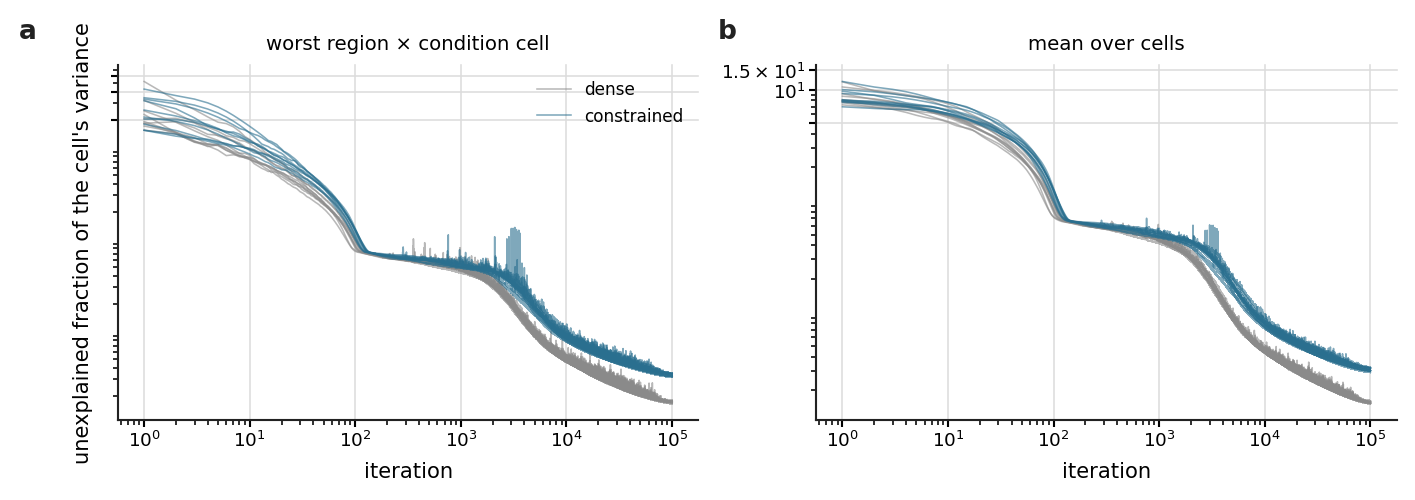

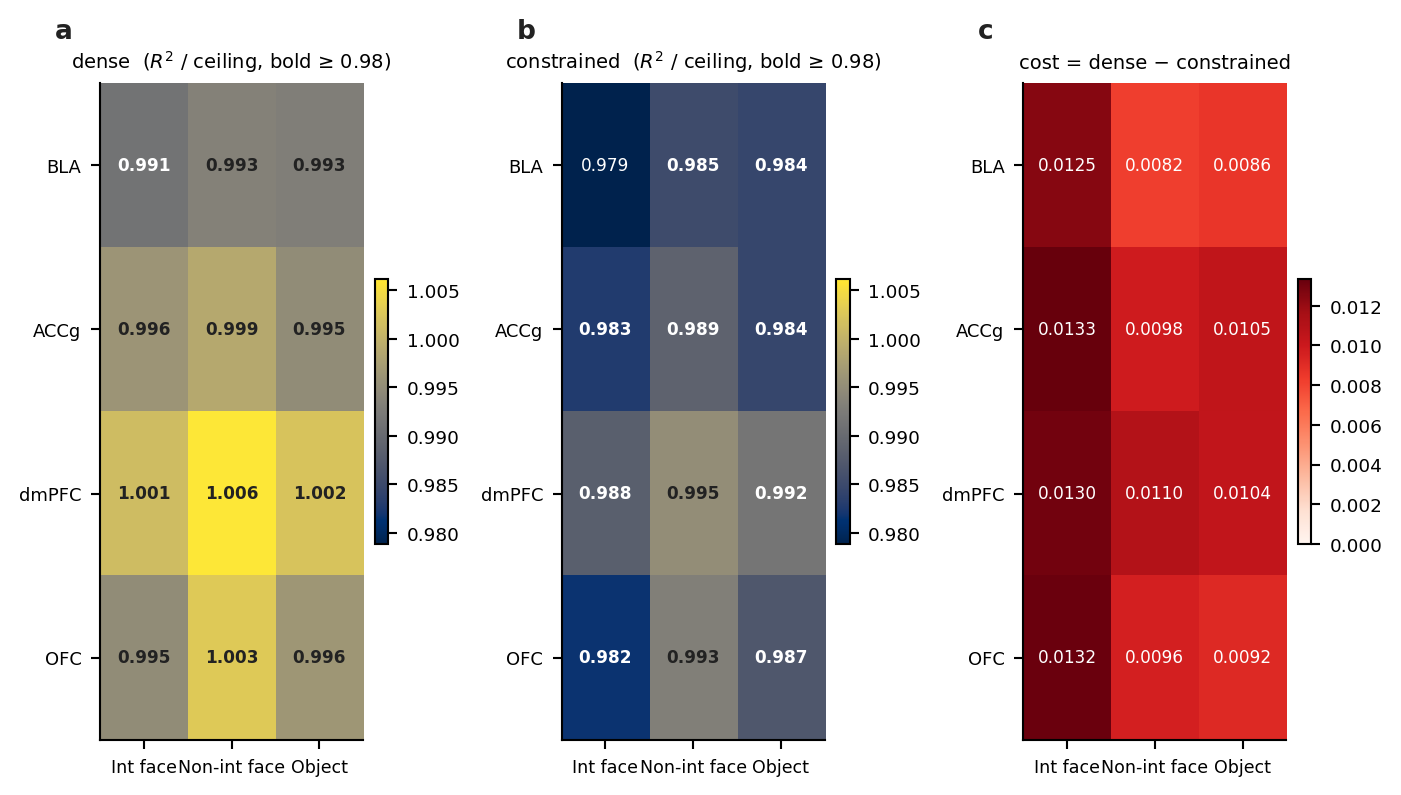

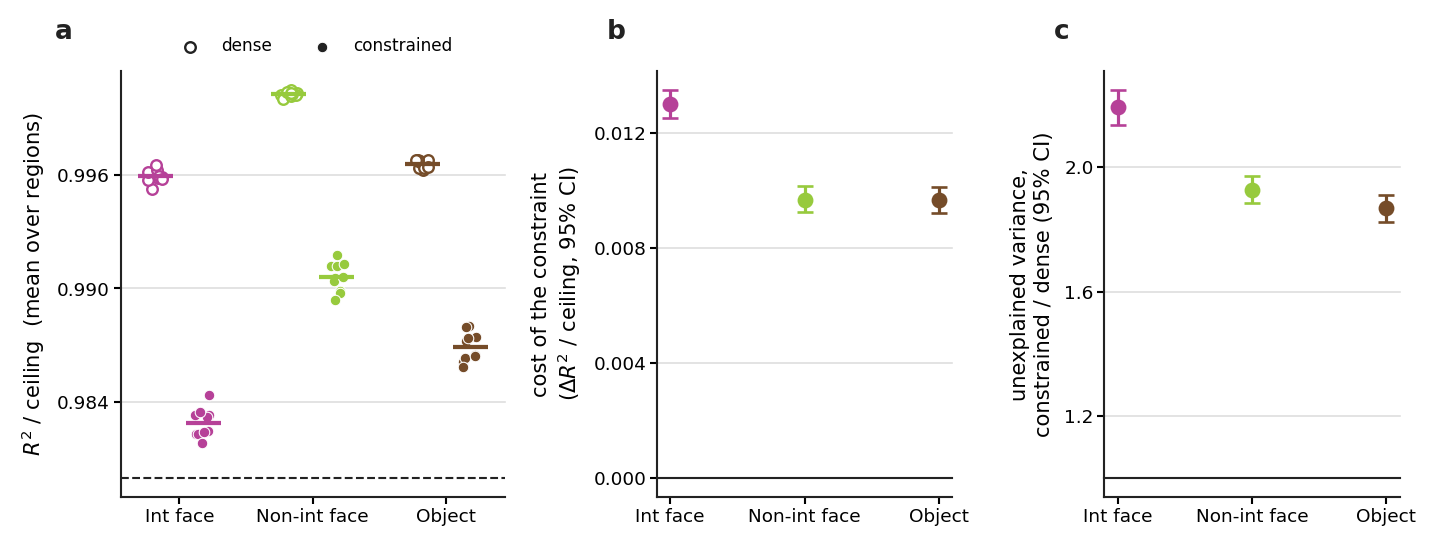

condition,face_interactive,face_non_interactive,object
dense_mean,0.9959,1.0003,0.9966
dense_sd,0.0003,0.0001,0.0002
constrained_mean,0.9829,0.9906,0.9869
constrained_sd,0.0008,0.0008,0.0008
cost,0.0130,0.0097,0.0097
cost_ci_low,0.0125,0.0092,0.0092
cost_ci_high,0.0135,0.0101,0.0101
unexplained_ratio,2.1925,1.9274,1.8678
unexplained_ratio_ci_low,2.1354,1.8838,1.8242
unexplained_ratio_ci_high,2.2488,1.9727,1.9119


In [4]:
ARMS = {}
if audit.seed_run_dirs(LADDER_ROOT / "full"):
    ARMS["dense"] = LADDER_ROOT / "full"
if variant is not None and audit.seed_run_dirs(TASK_ROOT / variant.label):
    ARMS["constrained"] = TASK_ROOT / variant.label

fit = None
if "constrained" not in ARMS:
    display(Markdown("*The ensemble has not been trained yet.*"))
else:
    done = inventory[inventory["complete"]]
    display(sweep.convergence_table(sweep.load_histories(done)).round(5))
    constrained_fit = cached("ensemble_fit", lambda: sweep.score_variant_fit(done, ceiling_by_region, ceiling_by_cell=ceiling_by_cell))
    dense_fit = pd.read_csv(LADDER_ROOT / "tables" / "ladder_fit_matched.csv")
    dense_fit = dense_fit[dense_fit["label"] == "full"]
    fit = pd.concat([dense_fit.assign(arm="dense"), constrained_fit.assign(arm="constrained")], ignore_index=True)
    fit["seed"] = fit["seed"].astype(str)
    # Task 02 selected on the worst *condition* (regions pooled per seed); the worst region x condition *cell* is stricter.
    worst = fit.groupby(["arm", "seed", "condition"])["r2_vs_ceiling"].mean().groupby(["arm", "seed"]).min().reset_index()
    worst_cell = fit.groupby(["arm", "seed", "region", "condition"])["r2_vs_ceiling"].mean().groupby(["arm", "seed"]).min().reset_index()
    summary = pd.concat([worst.groupby("arm")["r2_vs_ceiling"].agg(["mean", "min"]).add_prefix("worst condition, "),
                         worst_cell.groupby("arm")["r2_vs_ceiling"].agg(["mean", "min"]).add_prefix("worst cell, ")], axis=1)
    display(summary.round(4))
    _c = worst[worst["arm"] == "constrained"]["r2_vs_ceiling"]; _cc = worst_cell[worst_cell["arm"] == "constrained"]["r2_vs_ceiling"]
    display(Markdown(f"Constrained seeds clearing {ADEQUATE_BAR} on their worst condition (task 02's statistic): **{int((_c >= ADEQUATE_BAR).sum())}/{len(_c)}** "
                     f"(mean {_c.mean():.4f}; task 02's five seeds gave {SELECTED['worst_condition']:.4f}); on their worst region × condition cell: "
                     f"**{int((_cc >= ADEQUATE_BAR).sum())}/{len(_cc)}** (mean {_cc.mean():.4f})."))

    histories = {arm: [pd.read_csv(d / "history.csv") for d in audit.seed_run_dirs(p)] for arm, p in ARMS.items()}
    show(eviz.plot_loss_curves(histories), "fig01_loss_curves")
    show(eviz.plot_fit_cells_by_arm(fit, bar=ADEQUATE_BAR), "fig02_fit_cells")
    cost = cached("fit_cost_by_condition", lambda: ens.fit_cost_by_condition(constrained_fit, dense_fit))
    show(eviz.plot_condition_cost(fit, cost, bar=ADEQUATE_BAR), "fig03_condition_cost")
    display(cost.set_index("condition").round(4).T)

**Reading.** The ten constrained fits reproduce the five grid fits: worst condition 0.983
(bar 0.98) in every seed, worst region × condition cell 0.979 — the selected model sits *at*
the bar, not above it, and every constrained fit is within 0.002 of every other. Against
that, panel (b) of the cost figure is the test the grid could not run. The constraint costs
interactive face 0.0130 of ceiling-relative $R^2$ and the other two fixation types 0.0097
each; the extra cost to interactive face (0.0033, 95% CI 0.0027–0.0040) is positive in every
bootstrap draw. Panel (c) is the scale-free reading — unexplained variance, constrained over
dense — and says the same: ×2.19 for interactive face against ×1.93 and ×1.87. So the
answer to "does the bottleneck hurt one fixation type more" is yes, and it is interactive
face, *on top of* its being the hardest type in every network. The galleries below show what
that costs in the traces: ten constrained fits overlaid on the target, then ten dense.

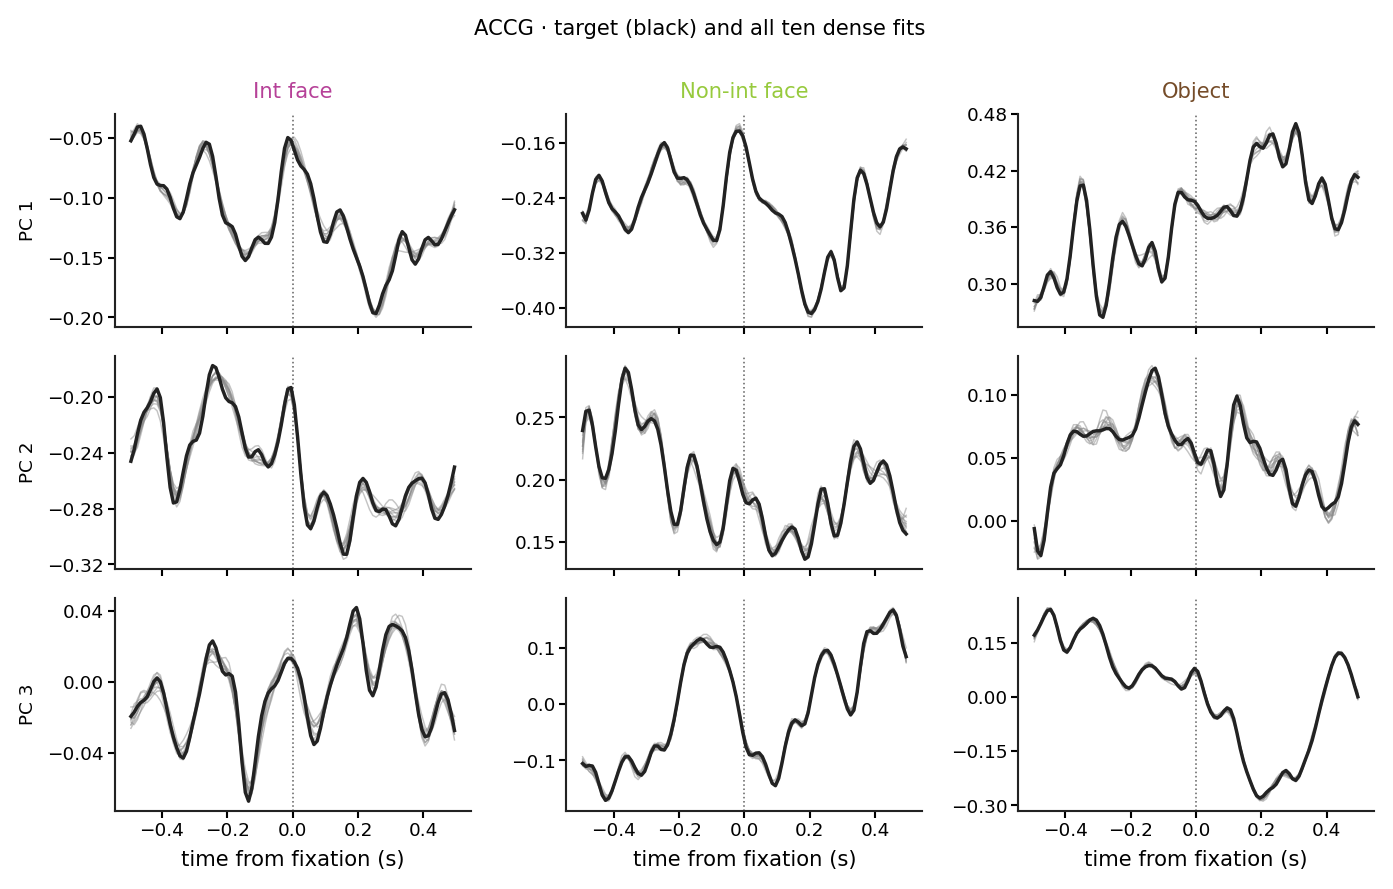

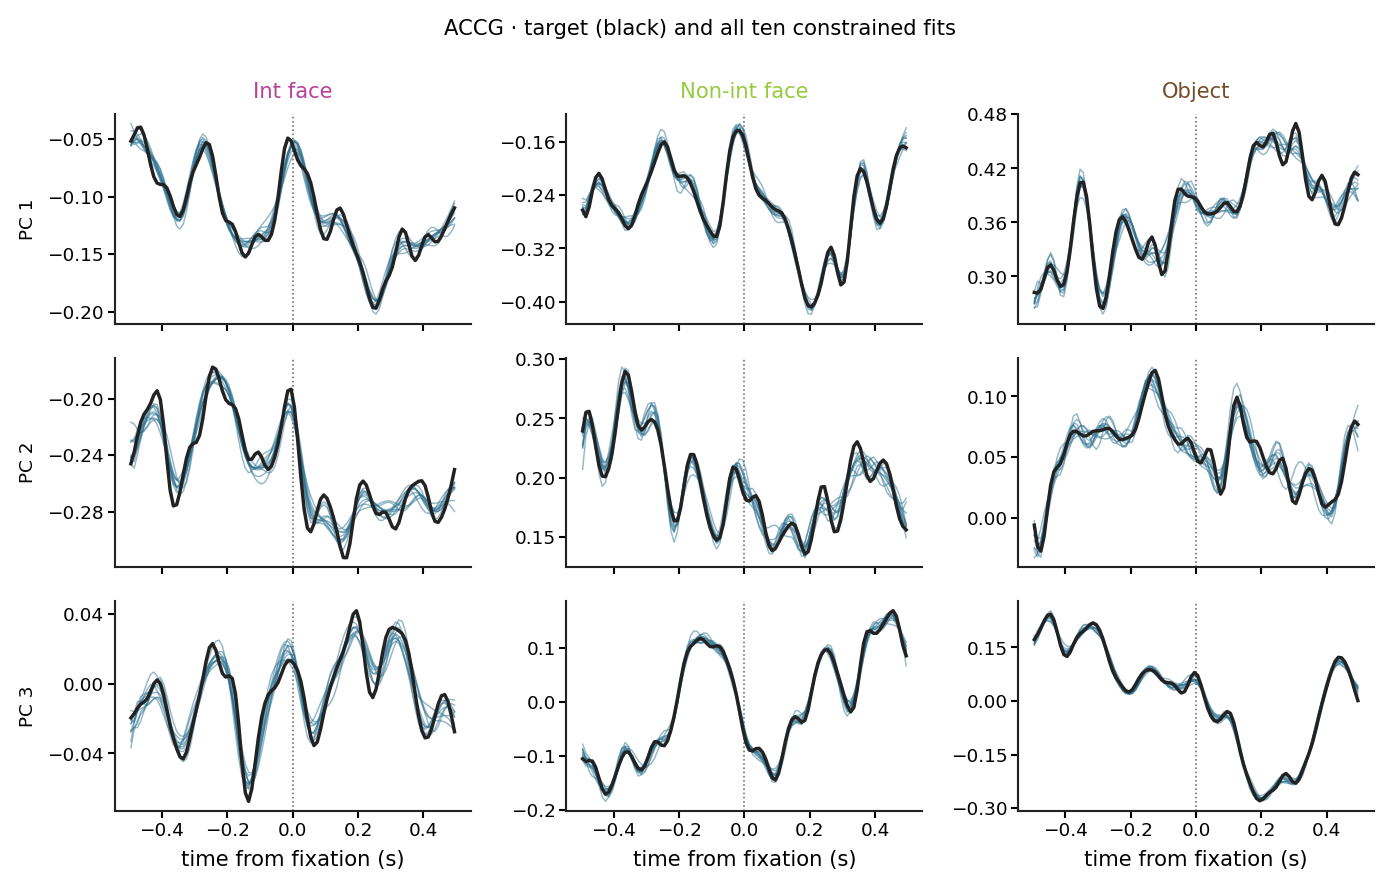

In [5]:
if fit is not None:
    for arm, path in ARMS.items():
        traces = cached(f"gallery_{GALLERY_REGION}_{arm}", lambda: ens.reconstruction_traces(audit.seed_run_dirs(path), region=GALLERY_REGION))
        traces["seed"] = traces["seed"].astype(str)
        show(eviz.plot_reconstruction_overlay(traces, arm=arm, title=f"{GALLERY_REGION.upper()} · target (black) and all ten {arm} fits"),
             f"fig04_gallery_{GALLERY_REGION}_{arm}")

## 4. Are the two faces alike?

For each property the model has as a time course per condition, the similarity of every
*pair* of conditions within one fit — **shape** (correlation after centring each
condition over its own time axis) and **distance** (RMS difference including offsets, over
the pooled spread). The **data** row is the reference: if the model's pairs are ordered the
way the data's are, the network inherits the similarity structure; if the model separates
the pairs further than the data does, it imposes one.

Chance for "FI–FN is the closest pair" is one in three.

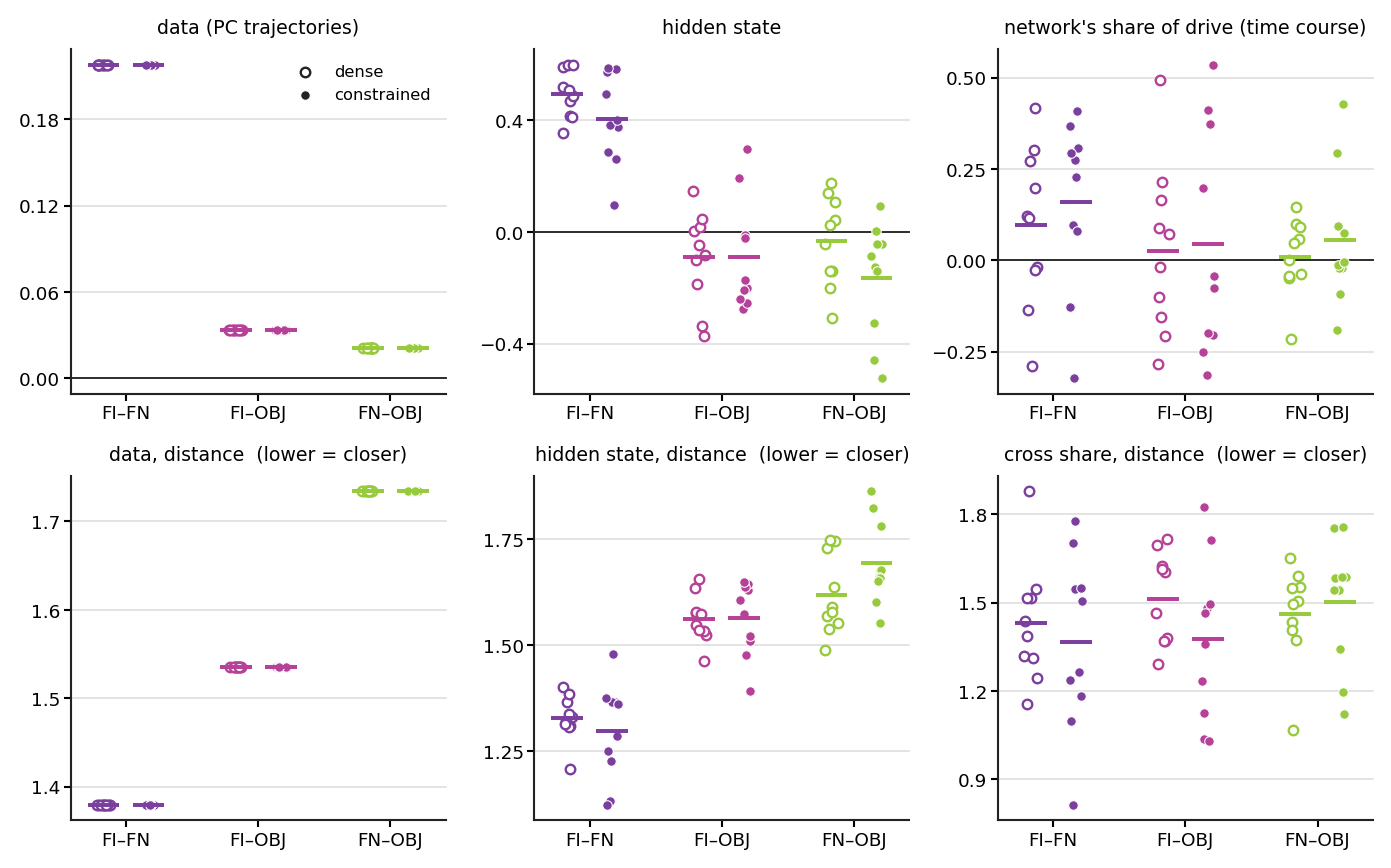

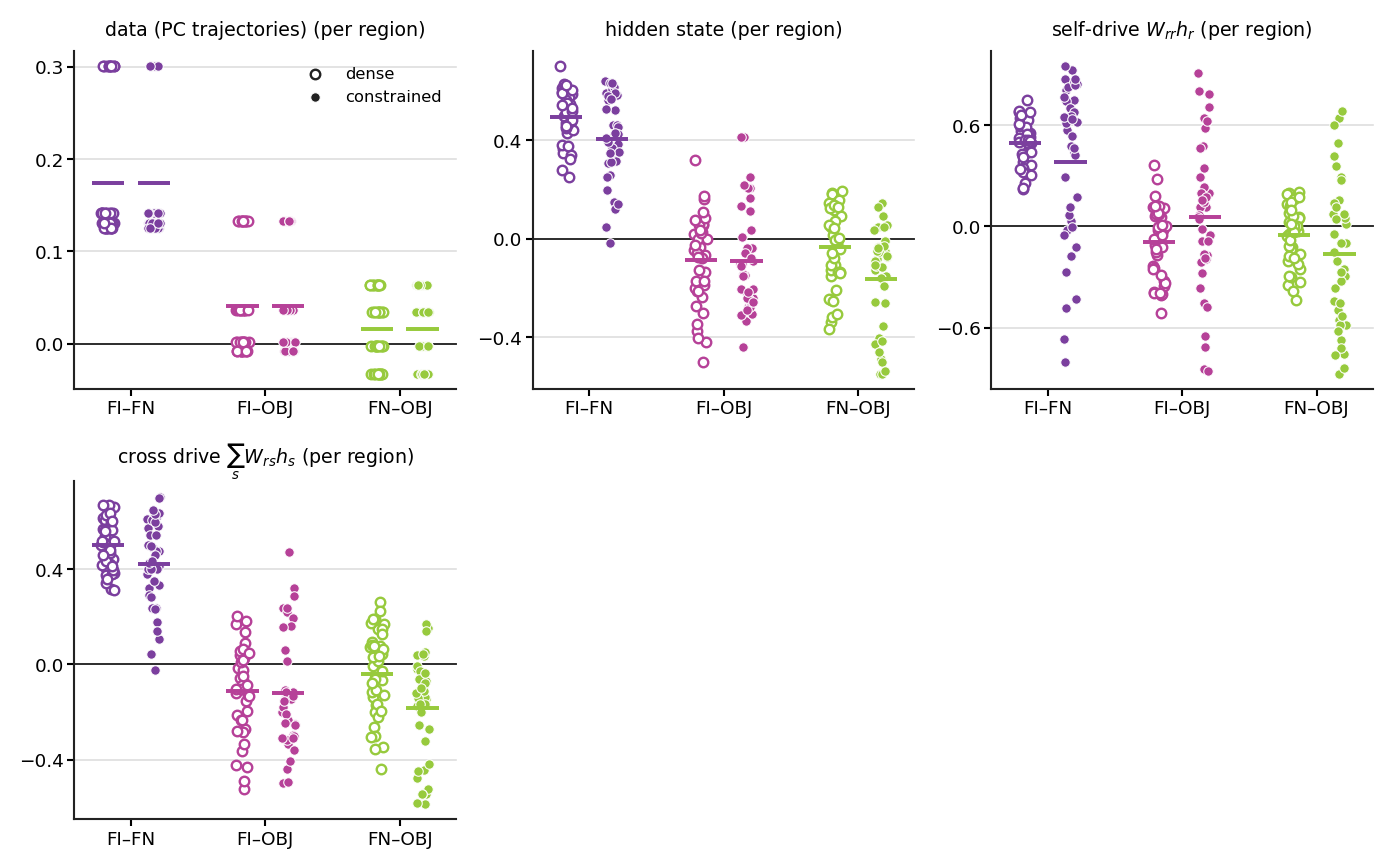

scope        kind  n_fits  FI–FN  \
arm         property                                                   
constrained cross_share           network  similarity      10  0.160   
            cross_share_distance  network    distance      10  1.367   
            state                 network  similarity      10  0.403   
            state_distance        network    distance      10  1.297   
            target                network  similarity      10  0.218   
            target_distance       network    distance      10  1.380   
dense       cross_share           network  similarity      10  0.096   
            cross_share_distance  network    distance      10  1.431   
            state                 network  similarity      10  0.494   
            state_distance        network    distance      10  1.328   
            target                network  similarity      10  0.218   
            target_distance       network    distance      10  1.380   

                                  FI–FN sd  FI–OBJ  FI–OBJ sd  FN–OBJ  \
arm         property                                                    
constrained cross_share              0.233   0.043      0.310   0.054   
            cross_share_distance     0.299   1.376      0.273   1.501   
            state                    0.161  -0.089      0.199  -0.165   
            state_distance           0.114   1.564      0.087   1.695   
            target                   0.000   0.034      0.000   0.021   
            target_distance          0.000   1.535      0.000   1.734   
dense       cross_share              0.215   0.026      0.231   0.009   
            cross_share_distance     0.203   1.513      0.155   1.463   
            state                    0.085  -0.091      0.165  -0.034   
            state_distance           0.054   1.563      0.056   1.618   
            target                   0.000   0.034      0.000   0.021   
            target_distance          0.000   1.535      0.000   1.734   

                                  FN–OBJ sd  fi_fn_closest  \
arm         property                                         
constrained cross_share               0.183            0.5   
            cross_share_distance      0.215            0.4   
            state                     0.204            1.0   
            state_distance            0.098            1.0   
            target                    0.000            1.0   
            target_distance           0.000            1.0   
dense       cross_share               0.103            0.5   
            cross_share_distance      0.163            0.4   
            state                     0.160            1.0   
            state_distance            0.093            1.0   
            target                    0.000            1.0   
            target_distance           0.000            1.0   

                                  fi_fn_closer_than_fi_obj  \
arm         property                                         
constrained cross_share                                0.6   
            cross_share_distance                       0.5   
            state                                      1.0   
            state_distance                             1.0   
            target                                     1.0   
            target_distance                            1.0   
dense       cross_share                                0.5   
            cross_share_distance                       0.6   
            state                                      1.0   
            state_distance                             1.0   
            target                                     1.0   
            target_distance                            1.0   

                                  fi_fn_closer_than_fn_obj  
arm         property                                        
constrained cross_share                                0.6  
            cross_share_distance                       0.7  
            state     

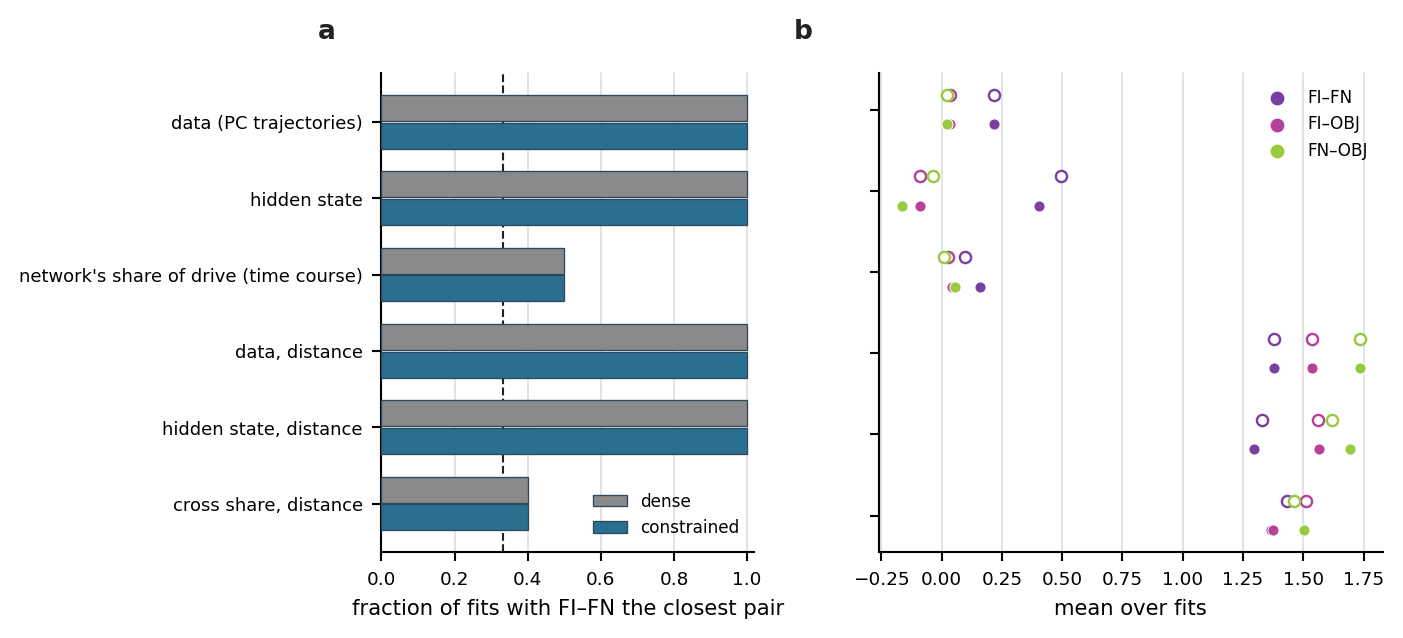

In [6]:
if fit is not None:
    similarity = cached("condition_similarity", lambda: over_arms(ens.condition_similarity))
    similarity["seed"] = similarity["seed"].astype(str)
    net = similarity[similarity["scope"] == "network"]
    show(eviz.plot_similarity_by_property(net, properties=["target", "state", "cross_share", "target_distance", "state_distance", "cross_share_distance"],
                                          labels=PROPERTY_LABELS), "fig05_similarity_network")
    show(eviz.plot_similarity_by_property(similarity[similarity["scope"] != "network"].assign(scope="region"),
                                          properties=["target", "state", "self_drive", "cross_drive"], scope="region",
                                          labels={k: v + " (per region)" for k, v in PROPERTY_LABELS.items()}), "fig06_similarity_regions")
    sim_summary = ens.similarity_summary(pd.concat([net, similarity[similarity["scope"] != "network"].assign(scope="region")]))
    display(sim_summary[sim_summary["scope"] == "network"].set_index(["arm", "property"]).round(3))
    show(eviz.plot_similarity_scoreboard(sim_summary[sim_summary["scope"] == "network"],
                                         properties=["target", "state", "cross_share", "target_distance", "state_distance", "cross_share_distance"],
                                         labels=PROPERTY_LABELS), "fig07_similarity_scoreboard")

**Reading.** In the data the two faces are the closest pair: their PC trajectories share
shape (correlation 0.22 against 0.03 and 0.02 for the two pairs involving object) and sit
closest (distance 1.38 against 1.54 and 1.73). The model's hidden state keeps that ordering
in 10/10 fits of both arms — and amplifies it: the two faces' state trajectories correlate
at 0.49 (dense) and 0.40 (constrained), twice the data's 0.22, while the pairs involving
object fall to zero or below. The drive's *routing* does not carry it: the time course of
the network's share of a region's drive puts FI–FN closest in only half the fits, chance for
three pairs. Per region the picture is the same (the second figure). The data row's fraction
is 1 by construction — it is the same data in every fit — and is there as the reference, not
as a consistency statistic.

## 5. Drive and flow in the final model

The 02b quantities on the ensemble: where each region's drive comes from, how that is
distributed over pathways and whether the seeds agree, how it moves through the trial, and
how it aligns with a region's own recurrence. Ten seeds per arm, every one on the page.

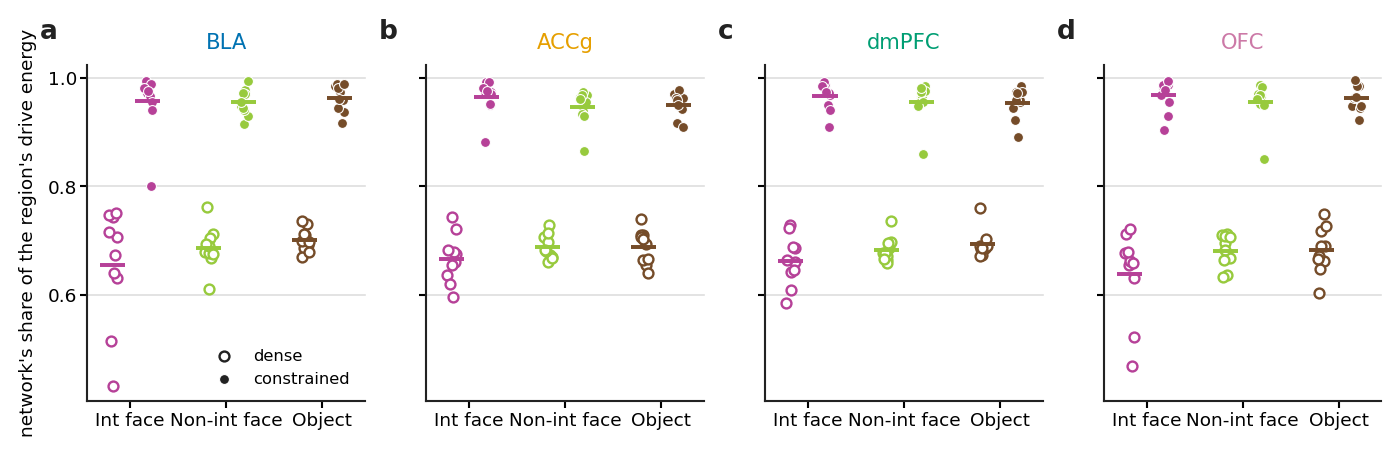

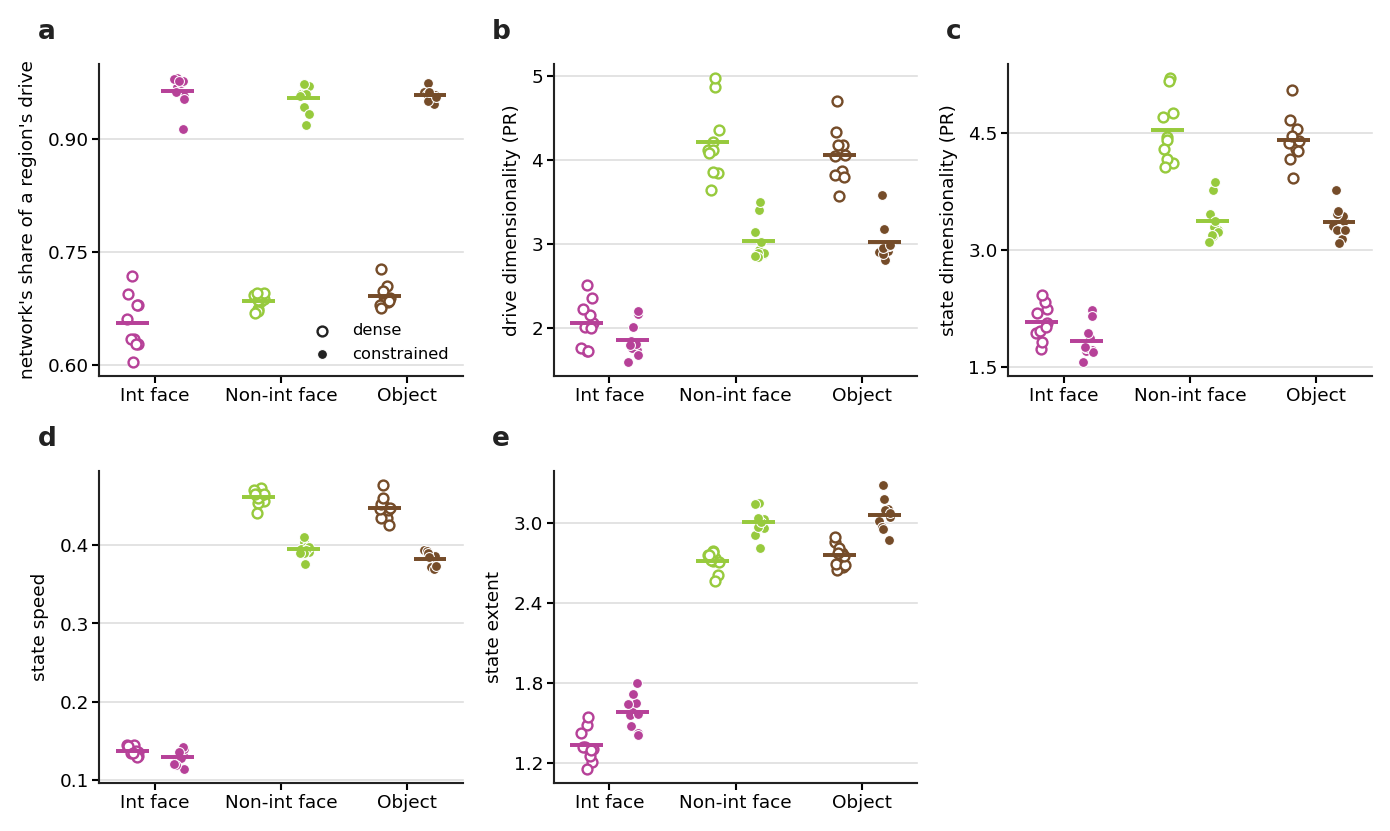

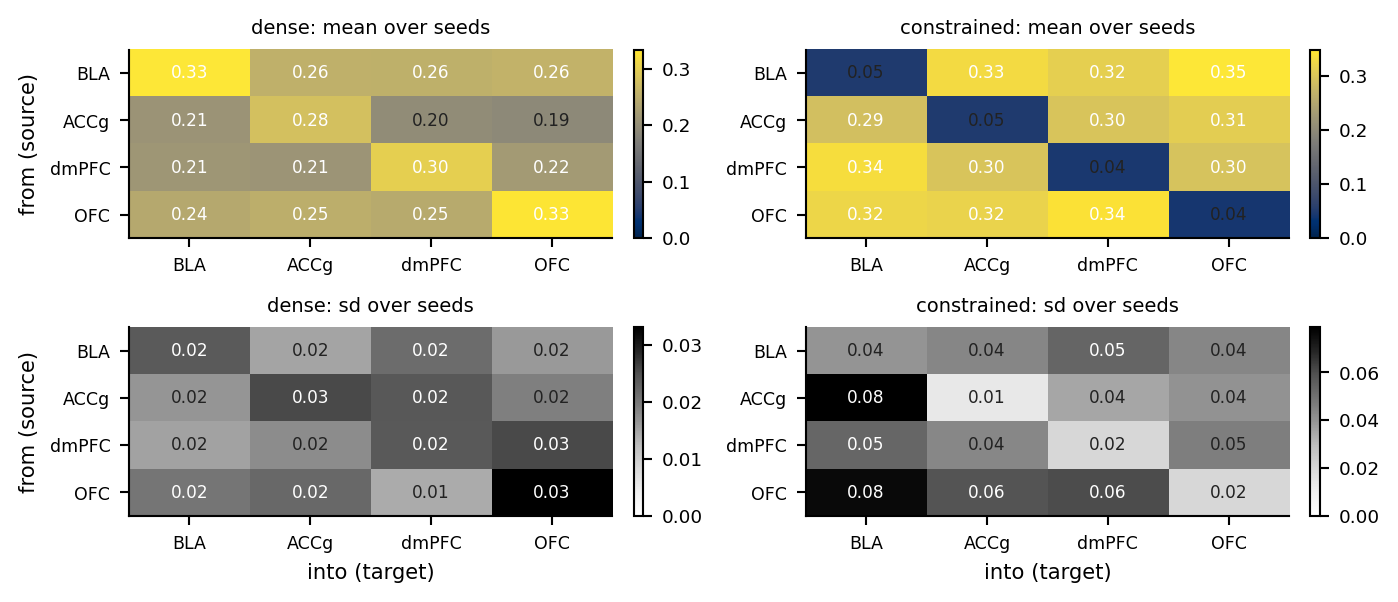

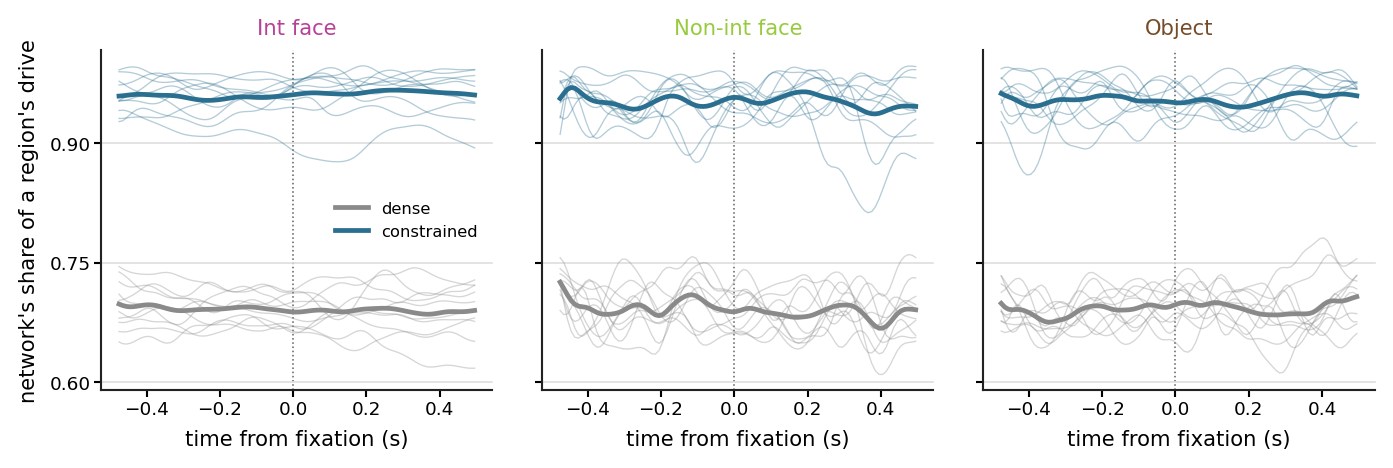

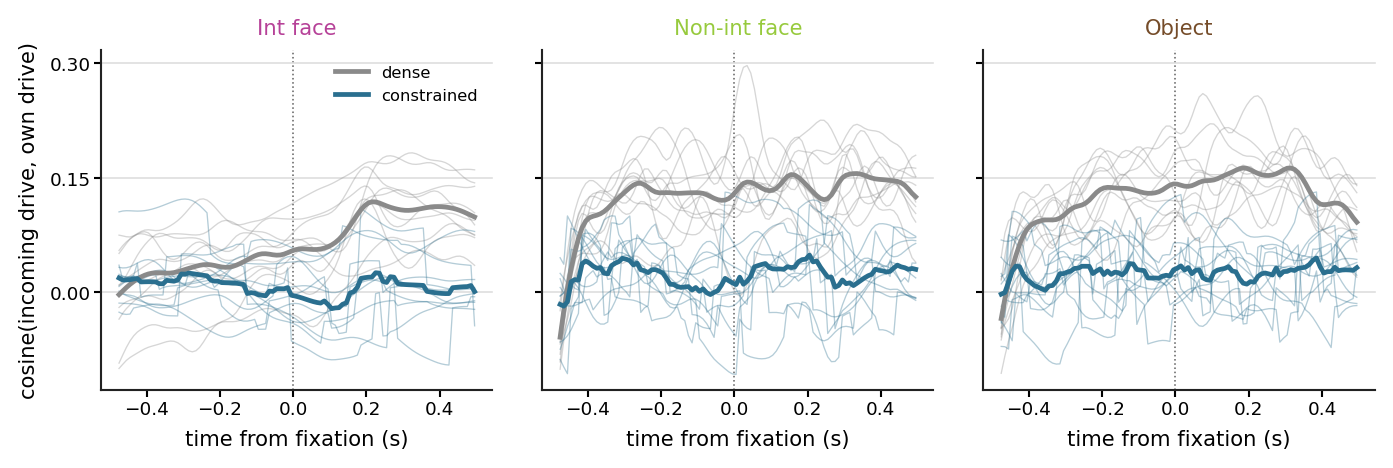

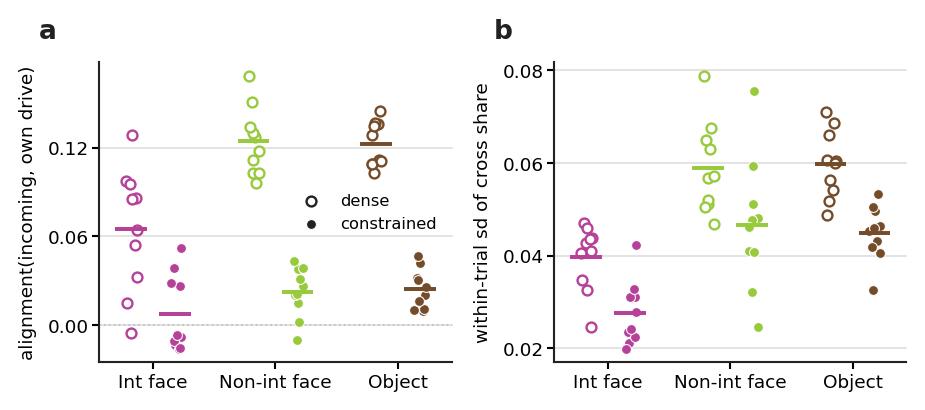

**Do the seeds agree on which pathways carry the most drive?** Kendall τ between seeds' pathway-share rankings (12 pathways):

,arm,n_seeds,pathway_share_tau_mean,tau_min
0,constrained,10,0.030,-0.455
1,dense,10,0.428,-0.061


In [7]:
if fit is not None:
    props = cached("region_state_properties", lambda: over_arms(audit.region_state_properties))
    props["seed"] = props["seed"].astype(str)
    show(eviz.plot_region_property_by_condition(props, "cross_energy_fraction", ylabel="network's share of the region's drive energy"),
         "fig08_cross_share_by_region")
    long_props = ens.to_long(props, ["cross_energy_fraction", "drive_pr", "state_pr", "state_speed", "state_extent"])
    show(eviz.plot_property_grid(long_props, ["cross_energy_fraction", "drive_pr", "state_pr", "state_speed", "state_extent"],
                                 labels=PROPERTY_LABELS), "fig09_state_properties")

    flow = cached("time_resolved_flow", lambda: over_arms(audit.time_resolved_flow))
    flow["seed"] = flow["seed"].astype(str)
    share = flow.assign(sq=flow["current_norm"] ** 2).groupby(["arm", "seed", "source", "target"])["sq"].mean().reset_index()
    share["share"] = share["sq"] / share.groupby(["arm", "seed", "target"])["sq"].transform("sum")
    show(eviz.plot_flow_matrix_two_arms(share), "fig10_flow_matrix")
    # Both arms share seed values (same protocol seeds), so the arm must ride along as ``label``.
    decomposed = audit.flow_decomposition(flow.assign(label=flow["arm"])).rename(columns={"label": "arm"})
    show(eviz.plot_time_course_two_arms(decomposed, "cross_fraction", ylabel="network's share of a region's drive"), "fig11_cross_share_time")

    alignment = cached("time_resolved_alignment", lambda: over_arms(audit.time_resolved_alignment))
    alignment["seed"] = alignment["seed"].astype(str)
    show(eviz.plot_time_course_two_arms(alignment, "cosine", ylabel="cosine(incoming drive, own drive)"), "fig12_alignment_time")
    align_long = (alignment.groupby(["arm", "seed", "condition"])["cosine"].mean().reset_index()
                  .rename(columns={"cosine": "value"}).assign(property="alignment"))
    temporal = audit.flow_temporal_summary(decomposed.assign(label=decomposed["arm"])).rename(columns={"label": "arm"})
    mod_long = ens.to_long(temporal, ["cross_fraction_modulation"])
    show(eviz.plot_property_grid(pd.concat([align_long, mod_long]), ["alignment", "cross_fraction_modulation"],
                                 labels=PROPERTY_LABELS, references={"alignment": 0.0}, n_cols=2), "fig13_alignment_modulation")

    # Pathway ranking agreement across seeds: do the ten fits agree on which pathways carry the most?
    from scipy.stats import kendalltau
    from itertools import combinations
    rows = []
    for arm, block in share[share["source"] != share["target"]].groupby("arm"):
        wide = block.groupby(["seed", "source", "target"])["share"].mean().unstack(["source", "target"])
        taus = [kendalltau(wide.iloc[i], wide.iloc[j]).statistic for i, j in combinations(range(len(wide)), 2)]
        rows.append({"arm": arm, "n_seeds": len(wide), "pathway_share_tau_mean": float(np.mean(taus)), "tau_min": float(np.min(taus))})
    display(Markdown("**Do the seeds agree on which pathways carry the most drive?** Kendall τ between seeds' pathway-share rankings (12 pathways):"))
    display(pd.DataFrame(rows).round(3))

**Reading.** Under the constraint every region takes ~0.96 of its drive energy from the
network, for every fixation type and every seed (dense: 0.68). Beyond that the routing is
not reproducible: the seeds agree moderately on which pathways carry the most drive in the
dense network (Kendall τ 0.43) and not at all under the constraint (0.03, minimum −0.46) —
the flow matrices' sd row shows the pathway shares moving by 0.05–0.12 between seeds. The
condition contrasts that do hold: interactive face's drive and state are the lowest-
dimensional (10/10, both arms) and its cross share is the *steadiest* through the trial
(within-trial sd lowest in 10/10 dense, 9/10 constrained). Alignment between incoming and
own drive is lowest for interactive face in 9/10 dense fits but only 6/10 constrained; under
the constraint it is near zero for every fixation type, as 02b found.

## 6. Dynamics

The input is a constant one-hot, so each condition is its own **autonomous system**
$h(t{+}1)=\tanh(Wh(t)+b_c)$: the three fixation types differ in where they start and in a
fixed offset $b_c$, and everything else is dynamics. Three views:

- **Fixed points** of each condition's map, found from many starts (states on the
  trajectory and noisy copies of them), polished by Newton's method, clustered, and
  linearised with the bias included. Reported: how many, how close the trajectory ends to
  the nearest one, and its stability.
- **Flow fields** in the plane of the top two state axes, whole network and per region.
  A region is not autonomous; its panel holds the drive it receives from the other three
  at its time average for that condition, and says so.
- **Local linearisation along the trajectory**: the Jacobian at every state the model
  actually visits, whole network and each region's own block (its intrinsic dynamics with
  input held fixed).

n_fixed_points  n_slow_points  \
arm         condition                                             
constrained face_interactive                 1.7            1.9   
            face_non_interactive             2.8            3.0   
            object                           2.5            3.0   
dense       face_interactive                 1.4            2.3   
            face_non_interactive             2.0            2.9   
            object                           2.0            2.9   

                                  nearest_distance_to_trajectory_end  \
arm         condition                                                  
constrained face_interactive                                   0.401   
            face_non_interactive                               0.749   
            object                                             0.763   
dense       face_interactive                                   0.470   
            face_non_interactive                               0.753   
            object                                             0.888   

                                  trajectory_end_speed  nearest_top_modulus  \
arm         condition                                                         
constrained face_interactive                     0.134                1.048   
            face_non_interactive                 0.389                1.063   
            object                               0.413                1.057   
dense       face_interactive                     0.172                1.040   
            face_non_interactive                 0.557                1.077   
            object                               0.620                1.055   

                                  nearest_n_expanding  
arm         condition                                  
constrained face_interactive                    4.900  
            face_non_interactive                3.000  
            object                              2.700  
dense       face_interactive                    7.333  
            face_non_interactive                6.400  
            object                              5.600

Fixed points that are stable (all |λ| < 1): **8/124** across both arms.

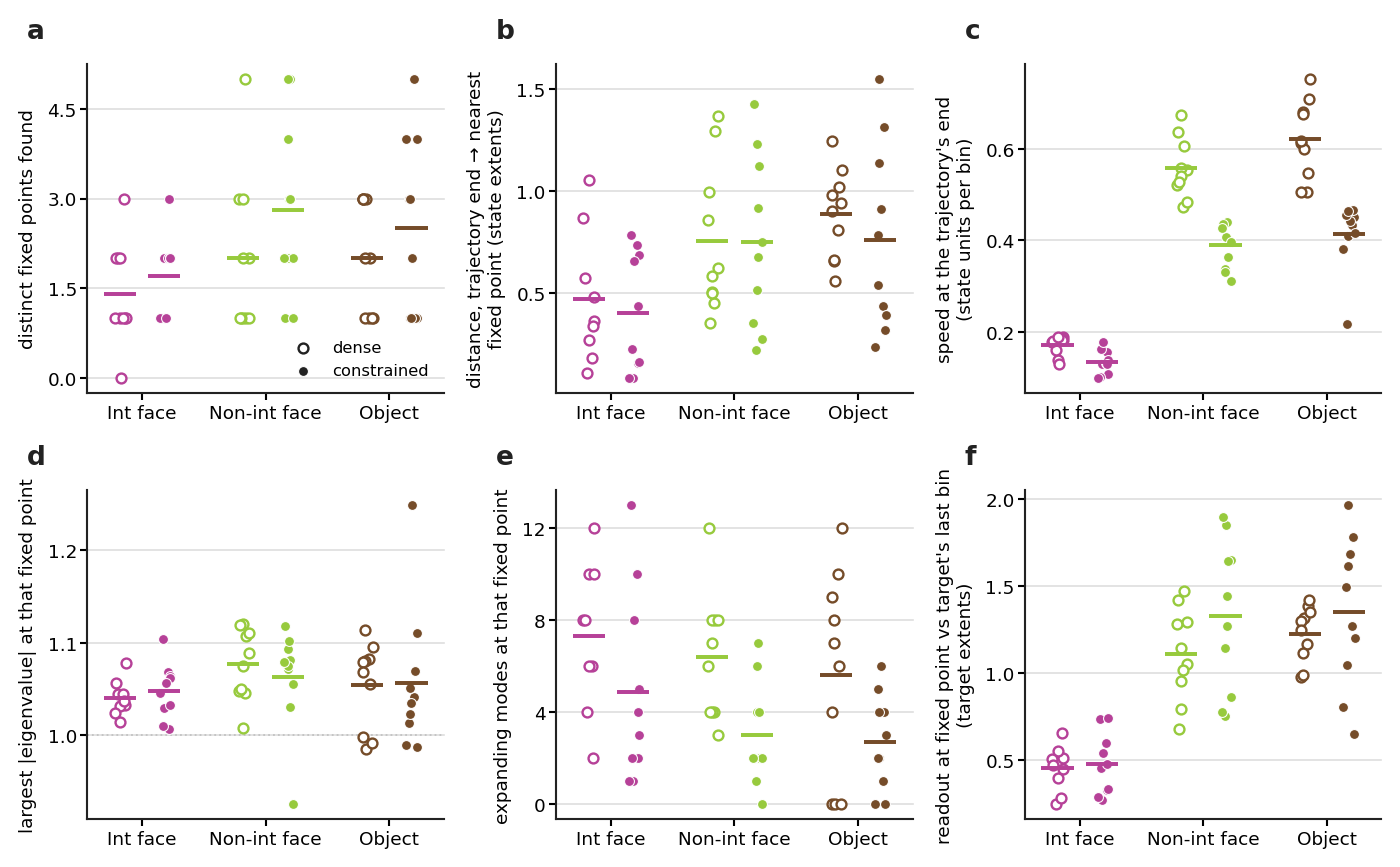

In [8]:
if fit is not None:
    _fp_paths = [TASK_ROOT / "tables" / f"fixed_points_{k}.csv" for k in ("points", "summary", "distances")]
    if all(p.exists() and p.stat().st_size > 1 for p in _fp_paths):
        fp_points, fp_summary, fp_distances = (pd.read_csv(p) for p in _fp_paths)
    else:
        fp_points, fp_summary, fp_distances = ens.ensemble_fixed_points(ARMS)
        for frame, p in zip((fp_points, fp_summary, fp_distances), _fp_paths):
            frame.to_csv(p, index=False)
    for frame in (fp_points, fp_summary, fp_distances):
        frame["seed"] = frame["seed"].astype(str)
    display(fp_summary.groupby(["arm", "condition"])[["n_fixed_points", "n_slow_points", "nearest_distance_to_trajectory_end",
                                                      "trajectory_end_speed", "nearest_top_modulus", "nearest_n_expanding"]].mean().round(3))
    display(Markdown(f"Fixed points that are stable (all |λ| < 1): **{int(fp_points['stable'].sum())}/{len(fp_points)}** across both arms."))
    show(eviz.plot_fixed_point_summary(fp_summary), "fig14_fixed_points")

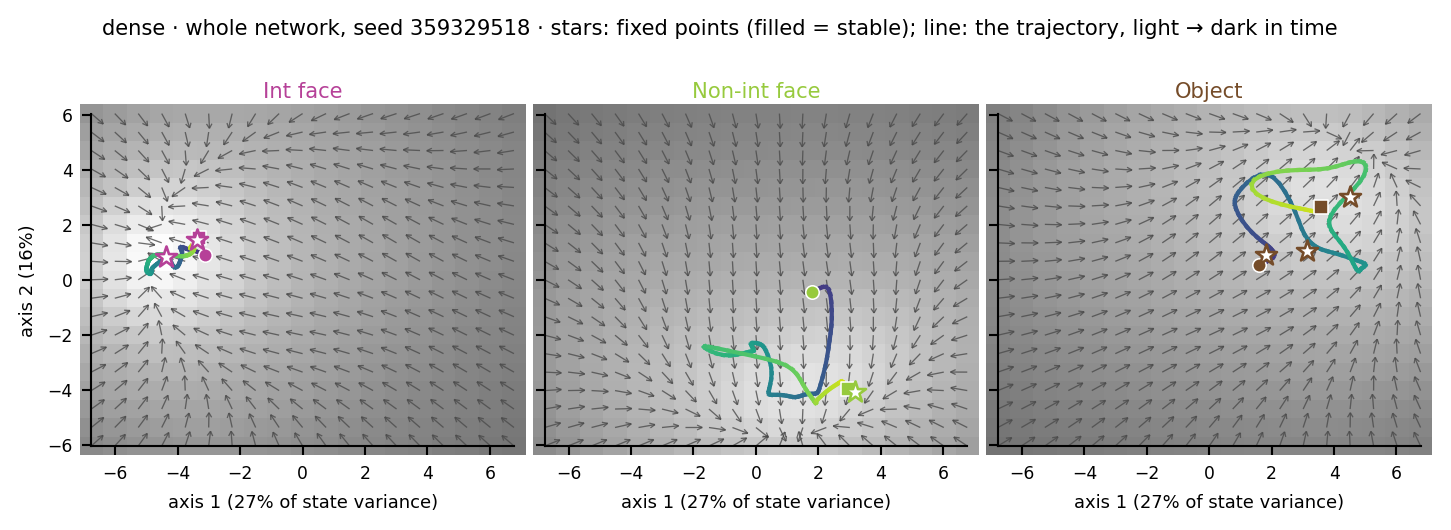

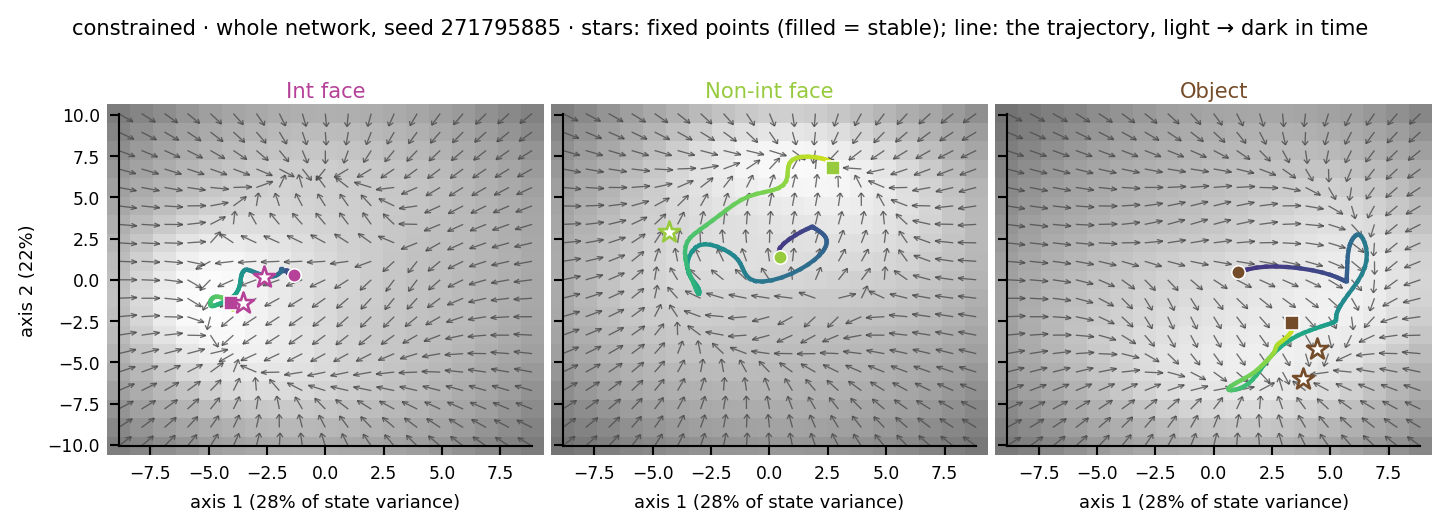

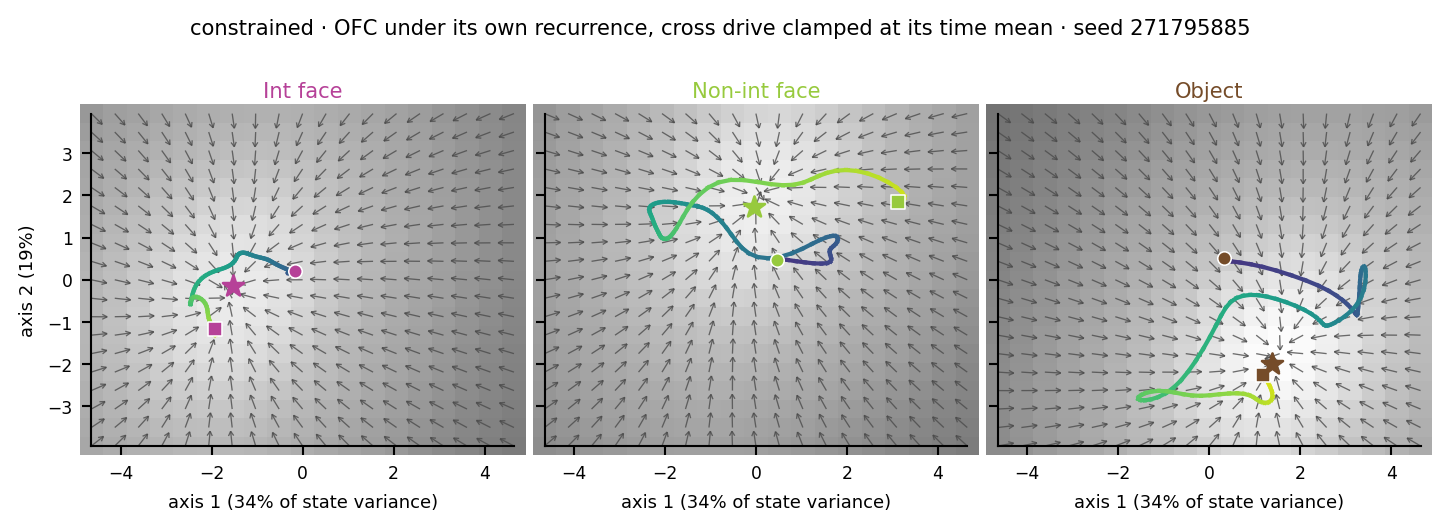

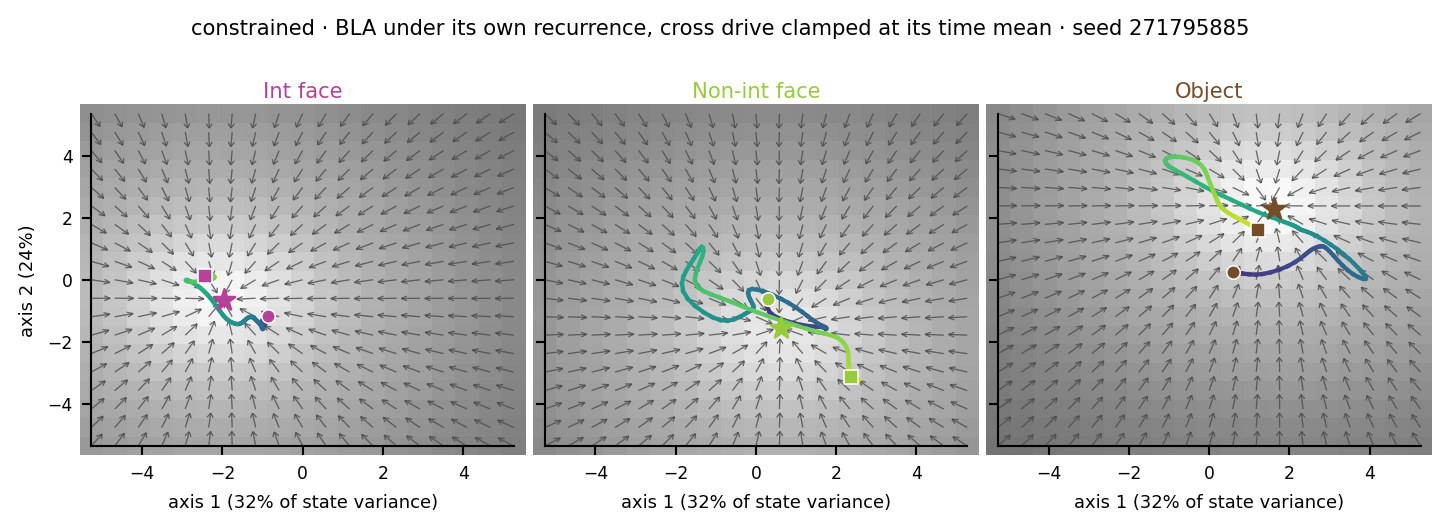

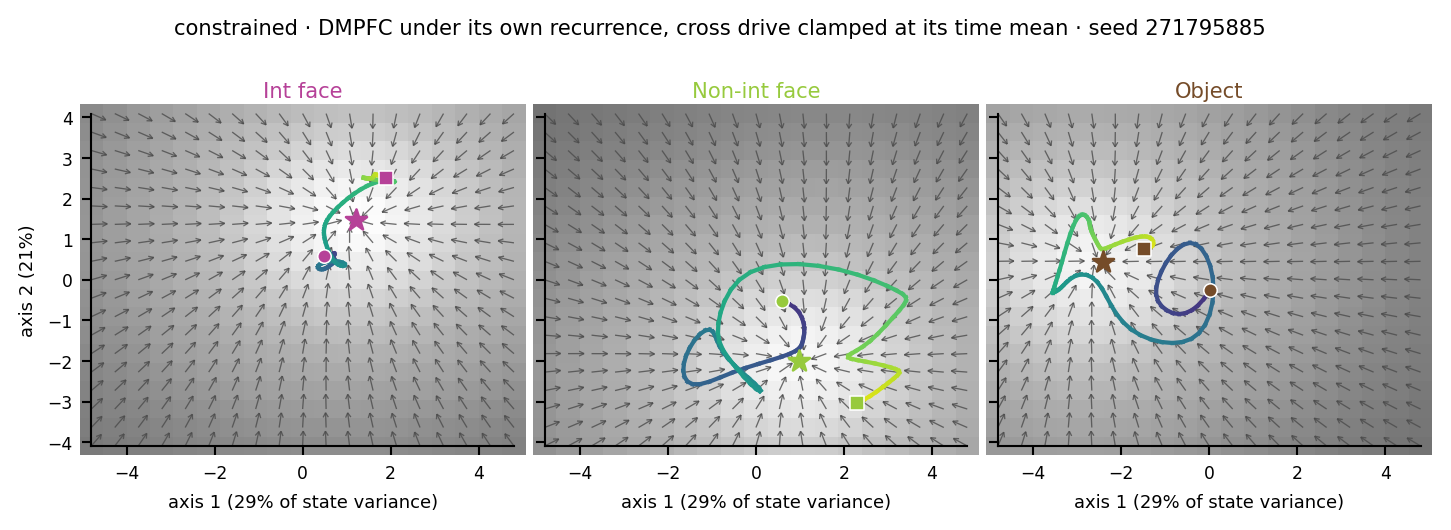

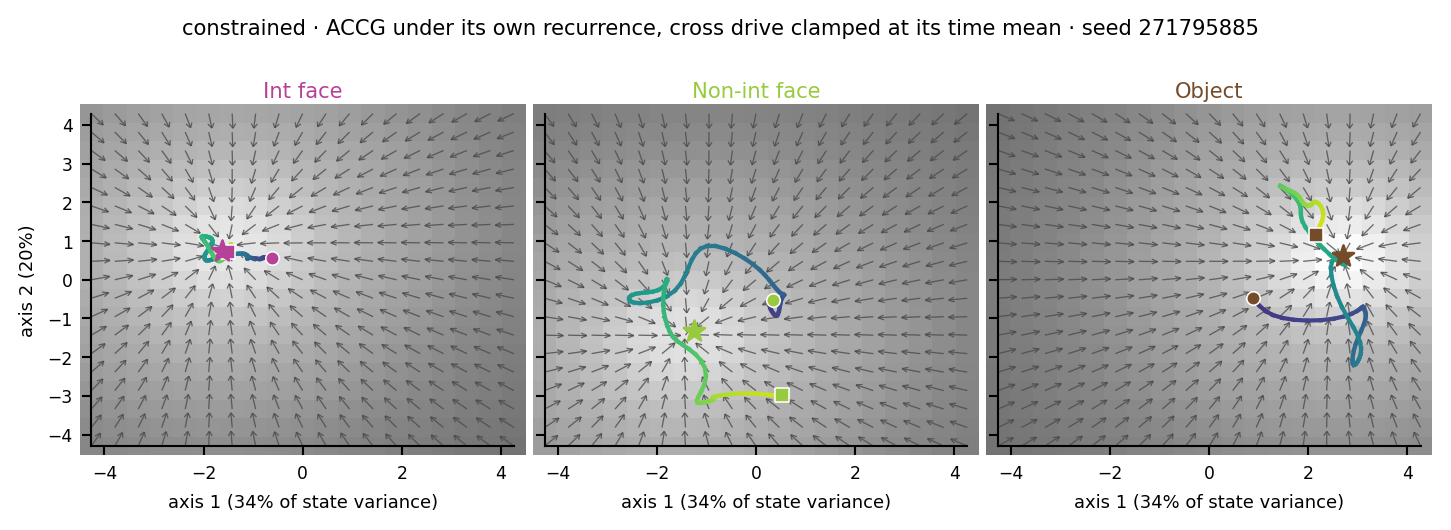

In [9]:
if fit is not None:
    # Representative seed per arm: the one whose worst cell sits at the median of its arm.
    rep = {}
    for arm in ARMS:
        w = worst[worst["arm"] == arm].sort_values("r2_vs_ceiling")
        rep[arm] = str(w.iloc[len(w) // 2]["seed"])
    for arm, path in ARMS.items():
        run_dir = next(d for d in audit.seed_run_dirs(path) if ens.seed_of(d) == rep[arm])
        fields = ens.flow_fields(run_dir, scope="network")
        show(eviz.plot_flow_fields(fields, title=f"{arm} · whole network, seed {rep[arm]} · stars: fixed points (filled = stable); line: the trajectory, light → dark in time"),
             f"fig15_flow_network_{arm}")
    run_dir = next(d for d in audit.seed_run_dirs(ARMS["constrained"]) if ens.seed_of(d) == rep["constrained"])
    for region in REGION_ORDER:
        fields = ens.flow_fields(run_dir, scope=region)
        show(eviz.plot_flow_fields(fields, title=f"constrained · {region.upper()} under its own recurrence, cross drive clamped at its time mean · seed {rep['constrained']}"),
             f"fig16_flow_{region}_constrained")

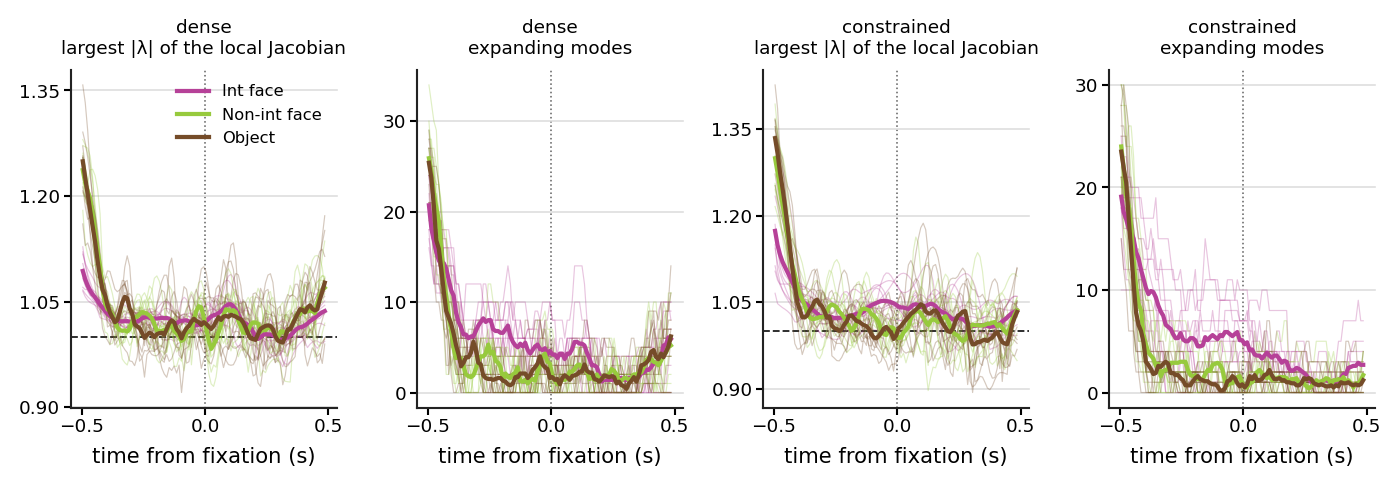

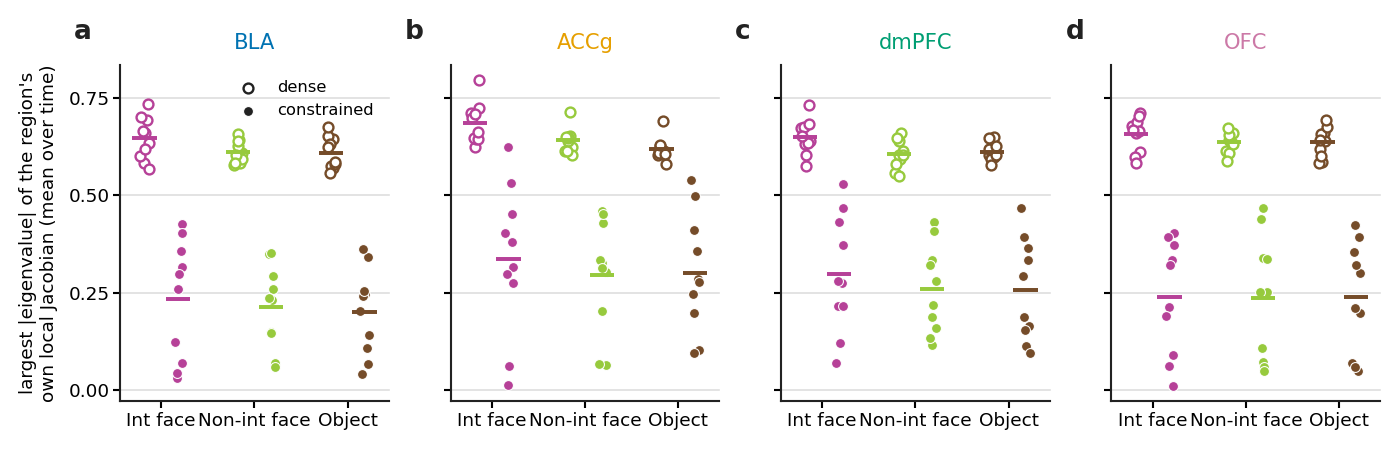

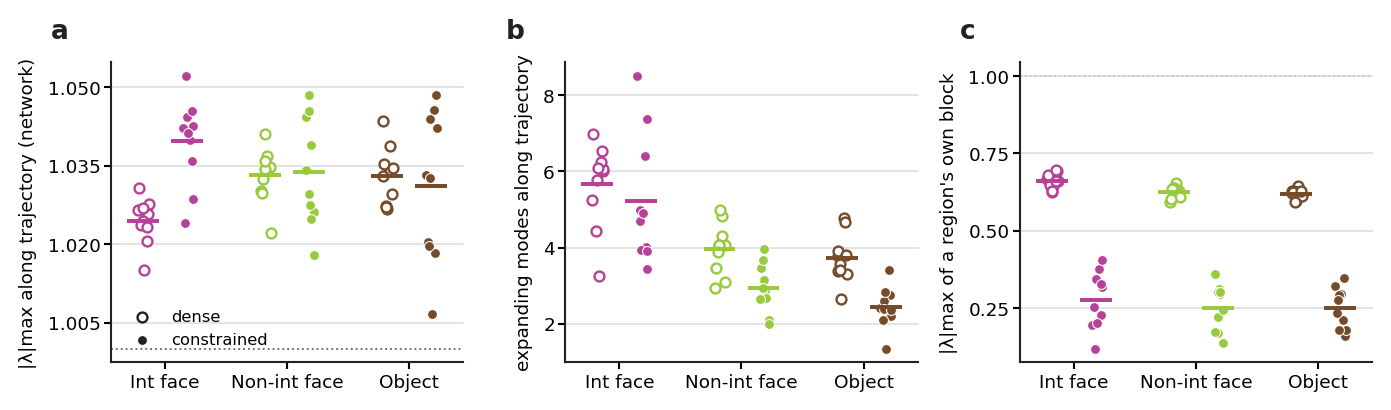

In [10]:
if fit is not None:
    jac = cached("jacobian_along_trajectory", lambda: over_arms(ens.jacobian_along_trajectory))
    jac["seed"] = jac["seed"].astype(str)
    show(eviz.plot_jacobian_time(jac, scope="network"), "fig17_jacobian_network_time")
    show(eviz.plot_region_timescales(jac), "fig18_region_block_timescales")
    jac_long = pd.concat([
        jac[jac["scope"] == "network"].groupby(["arm", "seed", "condition"])["top_modulus"].mean().reset_index()
           .rename(columns={"top_modulus": "value"}).assign(property="network_top_modulus"),
        jac[jac["scope"] == "network"].groupby(["arm", "seed", "condition"])["n_expanding"].mean().reset_index()
           .rename(columns={"n_expanding": "value"}).assign(property="network_n_expanding"),
        jac[jac["scope"] != "network"].groupby(["arm", "seed", "condition"])["top_modulus"].mean().reset_index()
           .rename(columns={"top_modulus": "value"}).assign(property="region_top_modulus"),
    ])
    show(eviz.plot_property_grid(jac_long, ["network_top_modulus", "network_n_expanding", "region_top_modulus"],
                                 labels=PROPERTY_LABELS, references={"network_top_modulus": 1.0, "region_top_modulus": 1.0}),
         "fig19_jacobian_by_condition")

**Reading.** (i) *The dynamics in the window are transient.* Of 124 fixed points found
across both arms, 8 are stable; the rest are saddles with 1–13 expanding modes and largest
|λ| of 1.04–1.06. No trajectory reaches a fixed point: at the end of the window the state is
still moving at 0.13–0.6 state units per bin and sits 0.4–0.9 state extents from the nearest
fixed point. The fixed points organise the flow the trajectory passes through; they do not
terminate it. (ii) *Interactive face is the fixation type nearest that organisation.* Its
trajectory ends slowest in 10/10 fits of both arms (0.13 against 0.39–0.41 constrained; 0.17
against 0.56–0.62 dense), ends nearest a fixed point (0.40 against 0.75 extents constrained,
7/10 fits; 0.47 against 0.75–0.89 dense), and runs through the most locally expansive part of
the flow: the most expanding modes along its trajectory in 10/10 constrained and 9/10 dense
fits (constrained: ~5 against ~1–2 after the initial transient). The whole-network flow
fields show it directly — a small loop beside the hollow stars, against the wide excursions
of the other two. (iii) *The within-region rank-1 constraint removes a region's own slow
dynamics.* With input held fixed, a region's block Jacobian has largest |λ| 0.60–0.70 in the
dense network (a ~20–30 ms intrinsic timescale) and 0.20–0.33 under the constraint
(~7 ms): the per-region flow fields are a single stable point the trajectory never
approaches, and everything slow arrives through the channel. Interactive face has the highest
region-block |λ| in 9/10 fits of both arms, but under the constraint the separation is below
the seed spread.

## 7. Lesions

Every directed, bidirectional, within-region and whole-region lesion, silenced in the
converged model, each with a matched random-weight control, damage in absolute squared
error (rebuild E4). Then the questions this ensemble can answer that a single fit cannot:
which **region pairs** matter, whether the ten fits agree, whether they agree *per fixation
type*, whether the fixation types are hurt by the same connections, where a pair lesion's
damage lands, and what a lesion does to the network's own dynamics rather than to its fit.

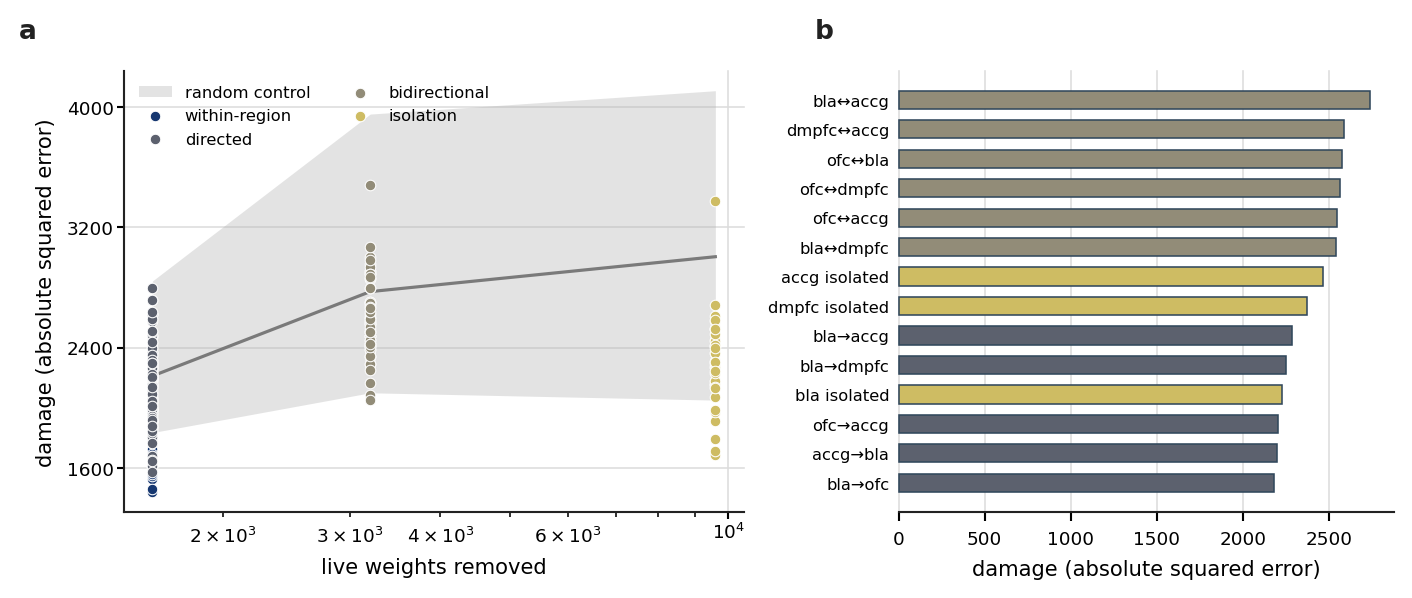

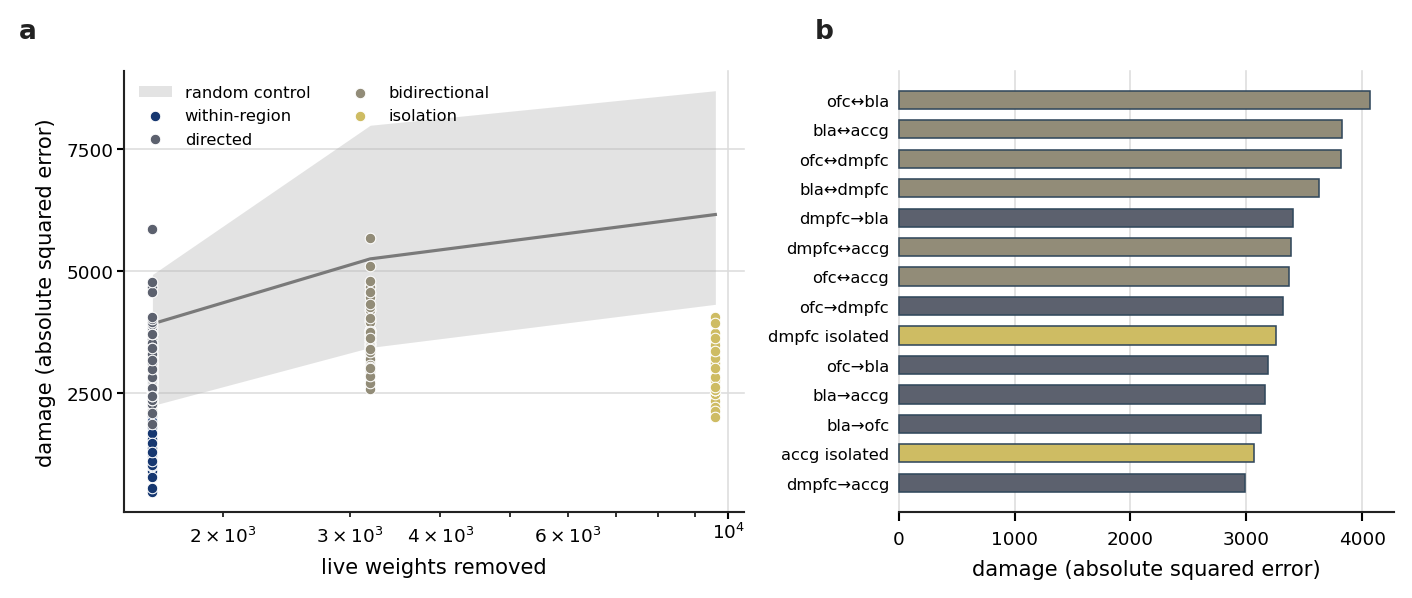

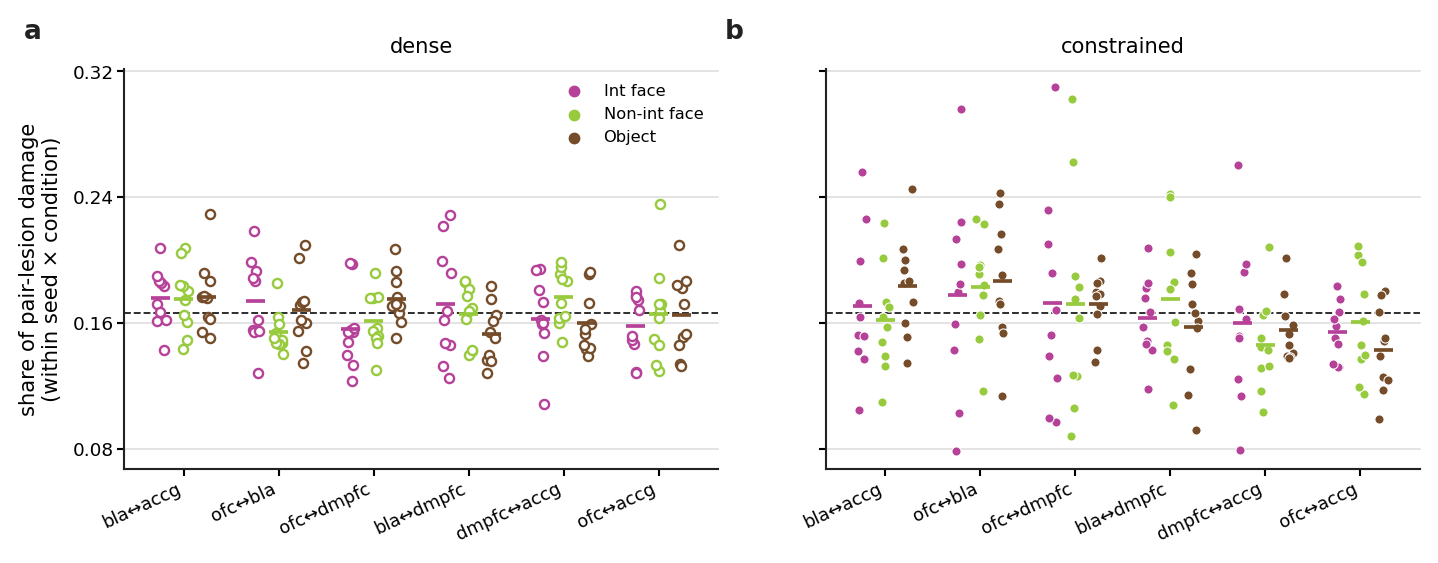

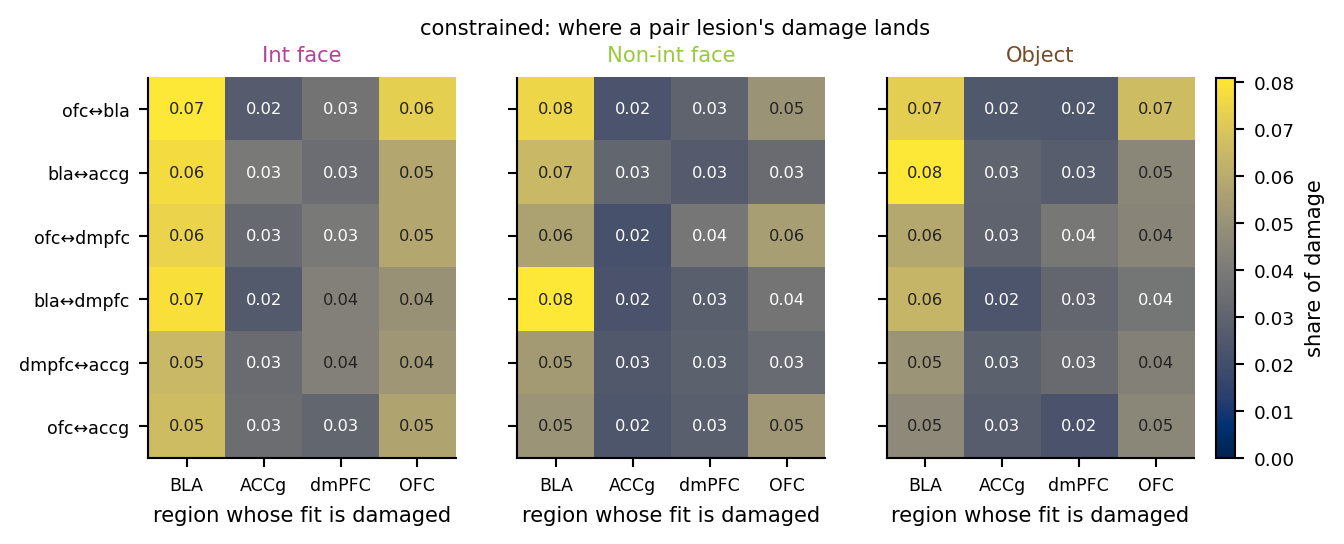

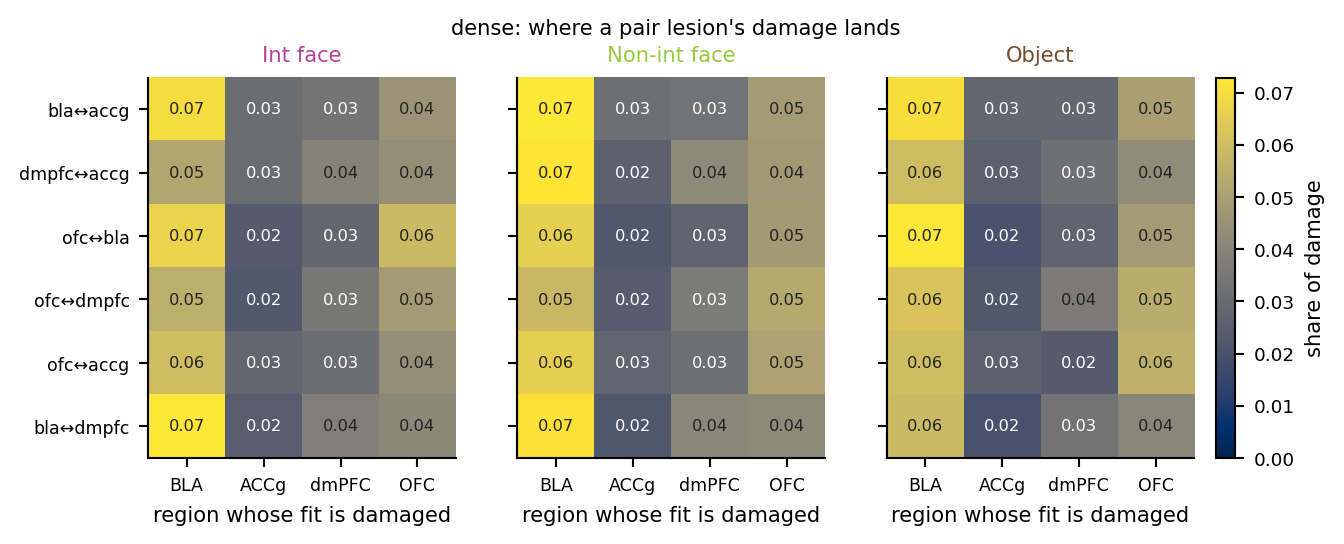

In [11]:
if fit is not None:
    lesions = cached("lesion_battery", lambda: pd.concat(
        [audit.lesion_battery(p).assign(arm=name) for name, path in ARMS.items() for p in audit.seed_run_dirs(path)], ignore_index=True))
    lesions["seed"] = lesions["seed"].astype(str)
    for name in ARMS:
        show(aviz.plot_lesion_battery(lesions, arm=name), f"fig20_lesion_battery_{name}")
    pairs = ens.pair_lesion_table(lesions)
    show(eviz.plot_pair_lesions(pairs), "fig21_pair_lesions")
    show(eviz.plot_pair_lesion_by_target(pairs, arm="constrained"), "fig22_pair_lesion_by_target_constrained")
    show(eviz.plot_pair_lesion_by_target(pairs, arm="dense"), "fig22_pair_lesion_by_target_dense")

,arm,lesion_kind,n_seeds,n_lesions,tau_mean,tau_min,null_mean,null_p95,clears_null
0,constrained,bidirectional,10,6,0.022,-0.733,-0.002,0.600,False
1,constrained,directed,10,12,0.029,-0.394,-0.014,0.364,False
2,constrained,isolation,10,4,0.089,-0.667,0.011,0.667,False
3,constrained,within-region,10,4,0.000,-1.000,0.002,0.667,False
4,dense,bidirectional,10,6,-0.007,-0.600,0.003,0.600,False
5,dense,directed,10,12,0.029,-0.424,-0.007,0.364,False
6,dense,isolation,10,4,0.022,-0.667,-0.009,0.667,False
7,dense,within-region,10,4,-0.067,-1.000,0.004,0.667,False


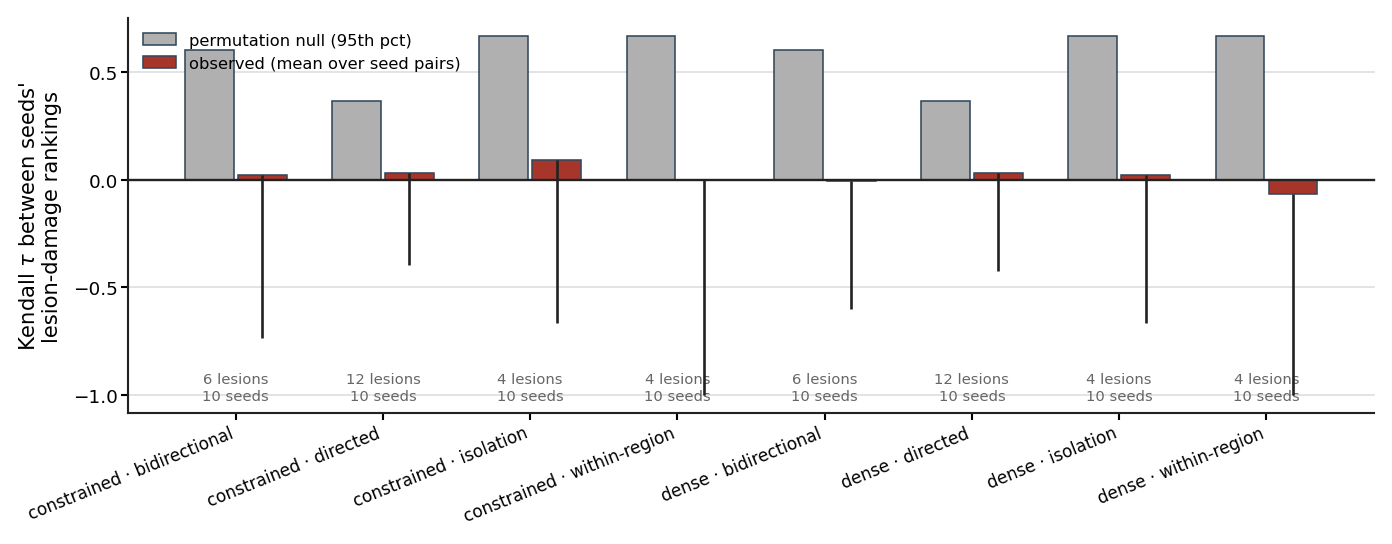

,arm,condition,lesion_kind,n_seeds,n_lesions,tau_mean,tau_min,null_p95,clears_null,top_lesion,top_lesion_is_top_in
0,constrained,face_interactive,bidirectional,10,6,-0.064,-0.867,0.600,False,ofc↔bla,0.3
1,constrained,face_non_interactive,bidirectional,10,6,-0.043,-0.600,0.600,False,ofc↔bla,0.1
2,constrained,object,bidirectional,10,6,0.040,-0.600,0.600,False,ofc↔bla,0.4
3,dense,face_interactive,bidirectional,10,6,-0.004,-0.733,0.600,False,bla↔accg,0.3
4,dense,face_non_interactive,bidirectional,10,6,0.067,-0.733,0.600,False,dmpfc↔accg,0.4
5,dense,object,bidirectional,10,6,0.052,-0.600,0.600,False,bla↔accg,0.1
6,constrained,face_interactive,directed,10,12,-0.026,-0.545,0.364,False,dmpfc→bla,0.1
7,constrained,face_non_interactive,directed,10,12,0.023,-0.424,0.364,False,dmpfc→bla,0.3
8,constrained,object,directed,10,12,0.030,-0.485,0.364,False,bla→accg,0.2
9,dense,face_interactive,directed,10,12,-0.013,-0.515,0.364,False,bla→accg,0.2


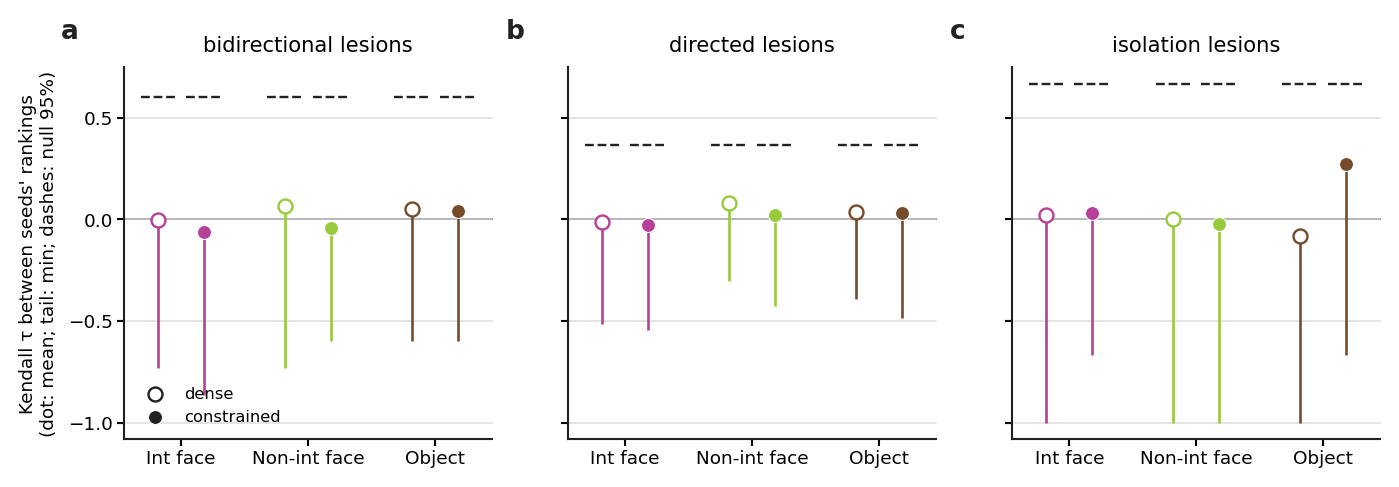

,arm,face_interactive__mean_sse,face_non_interactive__mean_sse,object__mean_sse,fraction_of_fits_fi_highest,fi_over_fn,n_seeds
0,constrained,924.4654,992.3508,995.9594,0.1,0.9164,10
1,dense,681.3136,771.1235,773.7829,0.0,0.8870,10


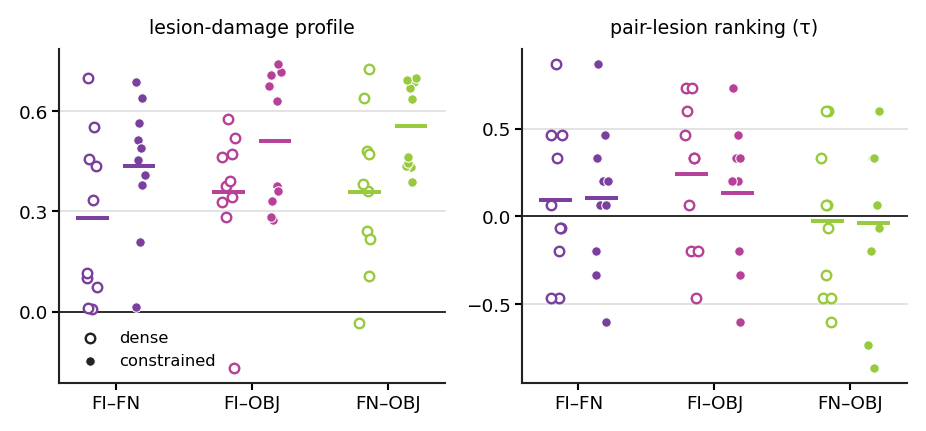

In [12]:
if fit is not None:
    ranking = cached("lesion_ranking_agreement", lambda: audit.lesion_ranking_agreement(lesions))
    display(ranking.round(3))
    show(aviz.plot_lesion_ranking_agreement(ranking), "fig23_ranking_agreement")
    ranking_cond = cached("lesion_ranking_by_condition", lambda: pd.concat(
        [ens.lesion_ranking_by_condition(lesions, kind=k) for k in ("bidirectional", "directed", "isolation")], ignore_index=True))
    display(ranking_cond.round(3))
    show(eviz.plot_lesion_ranking_by_condition(ranking_cond), "fig24_ranking_by_condition")
    contrast = cached("lesion_condition_contrast", lambda: audit.lesion_condition_contrast(lesions))
    display(contrast.round(4))
    cross_rank = ens.cross_condition_lesion_ranking(lesions)
    lesion_sim = ens.lesion_profile_similarity(lesions)
    show(eviz.plot_similarity_by_property(pd.concat([lesion_sim, cross_rank]), properties=["lesion_profile", "lesion_ranking_bidirectional"],
                                          labels=PROPERTY_LABELS), "fig25_lesion_profile_similarity")

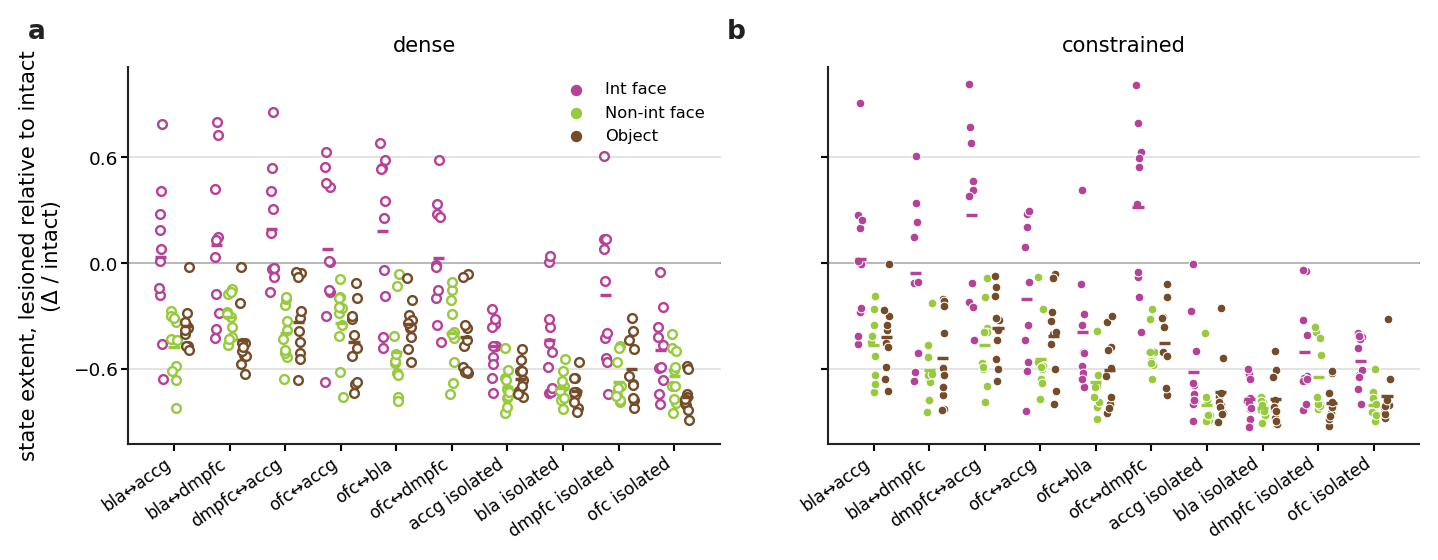

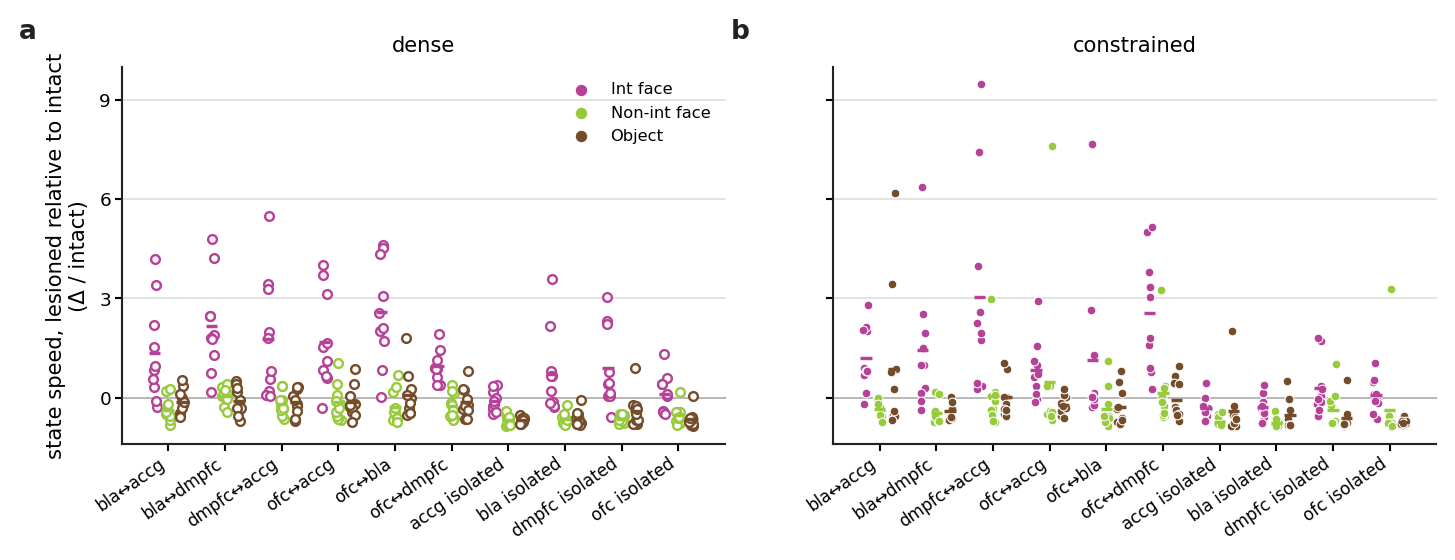

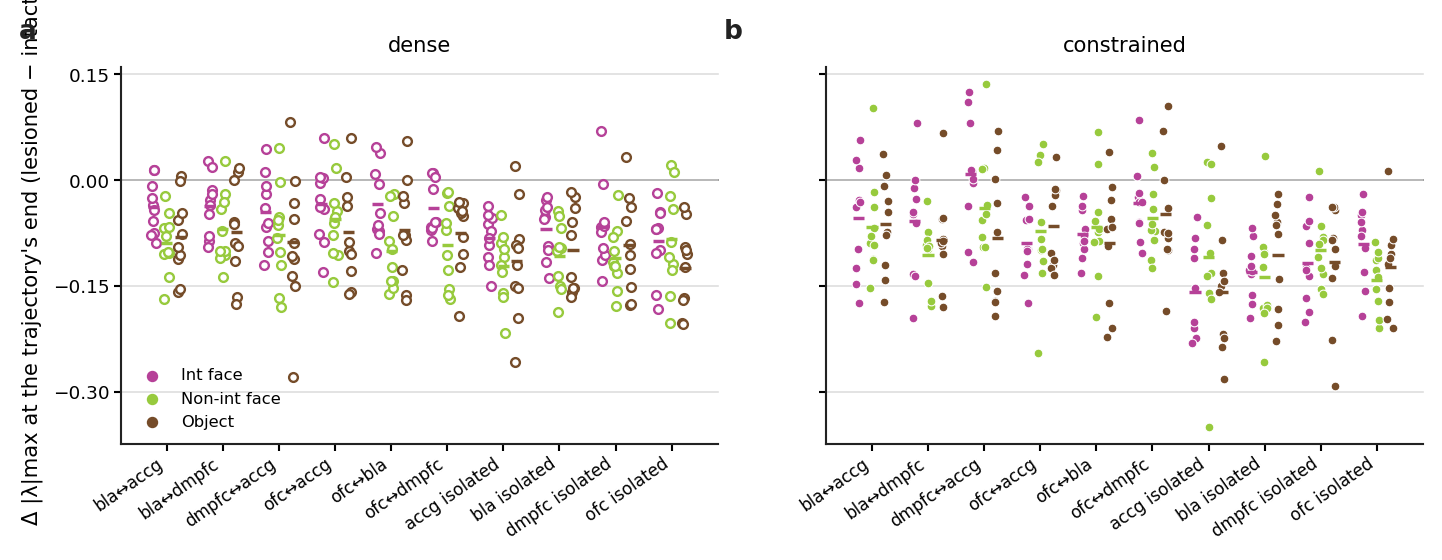

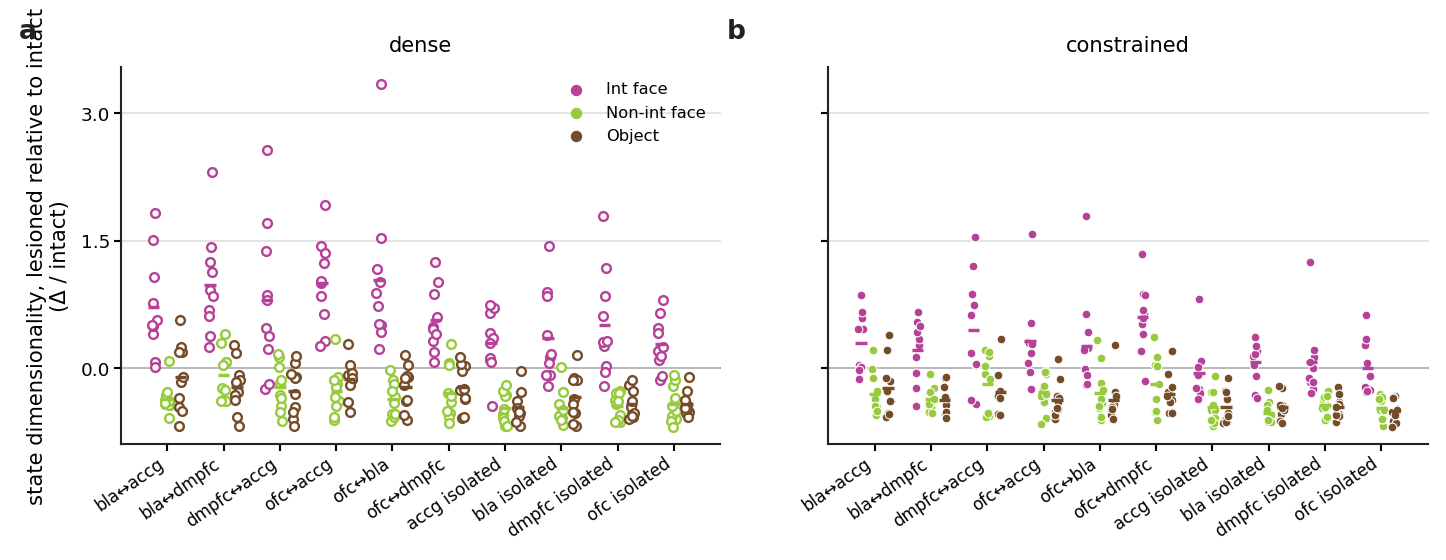

,weight_spectral_radius,weight_n_outside_unit
arm,,
constrained,1.479,34.5
dense,1.368,40.6


In [13]:
if fit is not None:
    lesion_dyn = cached("lesion_dynamics", lambda: over_arms(ens.lesion_dynamics))
    lesion_dyn["seed"] = lesion_dyn["seed"].astype(str)
    # Relative to the intact trajectory, so a fixation type with a small trajectory is not read as "less affected" for that reason.
    _intact = lesion_dyn[lesion_dyn["lesion_kind"] == "intact"].set_index(["arm", "seed", "condition"])
    for metric in ("state_extent", "state_speed", "state_pr"):
        lesion_dyn[f"rel_{metric}"] = lesion_dyn[f"delta_{metric}"] / pd.MultiIndex.from_frame(lesion_dyn[["arm", "seed", "condition"]]).map(_intact[metric])
    show(eviz.plot_lesion_dynamics(lesion_dyn, metric="rel_state_extent", ylabel="state extent, lesioned relative to intact\n(Δ / intact)"), "fig26_lesion_delta_extent")
    show(eviz.plot_lesion_dynamics(lesion_dyn, metric="rel_state_speed", ylabel="state speed, lesioned relative to intact\n(Δ / intact)"), "fig26b_lesion_delta_speed")
    show(eviz.plot_lesion_dynamics(lesion_dyn, metric="delta_end_top_modulus", ylabel="Δ |λ|max at the trajectory's end (lesioned − intact)"), "fig27_lesion_delta_modulus")
    show(eviz.plot_lesion_dynamics(lesion_dyn, metric="rel_state_pr", ylabel="state dimensionality, lesioned relative to intact\n(Δ / intact)"), "fig28_lesion_delta_pr")
    display(lesion_dyn[lesion_dyn["lesion_kind"] == "intact"].groupby(["arm"])[["weight_spectral_radius", "weight_n_outside_unit"]].mean().round(3))

**Reading.** *Which connections matter is not a reproducible property of these fits.* No
lesion family's ranking clears its permutation null in either arm (Kendall τ between seeds
≤ 0.09 for directed, pair, isolation and within-region lesions), and neither does any
ranking computed per fixation type: the pair that hurts most is the top pair in at most 4 of
10 fits, for any fixation type, in either arm. The pair-share panels say the same thing at
a glance — every pair scatters around one sixth, with the seed spread wider than any pair
difference. Nor are the fixation types hurt by different connections: their lesion profiles
correlate at 0.3–0.55 with no pair ordering, and their pair rankings agree at τ ≈ 0.1.
Interactive face is damaged *least* in absolute squared error (highest in 1/10 fits) —
the variance confound reversed; it has the least to lose.

*What a lesion does to the dynamics is reproducible, and it separates interactive face.*
Cutting any region pair shrinks the trajectories of non-interactive face and object — by
40–55% of their intact extent, in every seed and every pair of both arms — and leaves
interactive face's on average unchanged (expanded in about half of the seed × pair cases,
shrunk in the rest; least affected of the three in 10/10 seeds). Isolating a region shrinks
all three, interactive face least. The intact network's inter-regional drive therefore does
two different things: it drives the other two fixation types *out* into their excursions,
and for interactive face it is as often holding the state *in* as pushing it out.

## 8. Identifiability, for the record

The rebuild's agreement battery (seven measures, three distances, each against fits of the
untrained architecture with the same rank constraints), constrained beside dense. Every
similarity margin is at or below zero in both arms — the constrained fits agree *less* on
their state geometry than untrained networks do — so the within-model framing above is
necessary, not a choice.

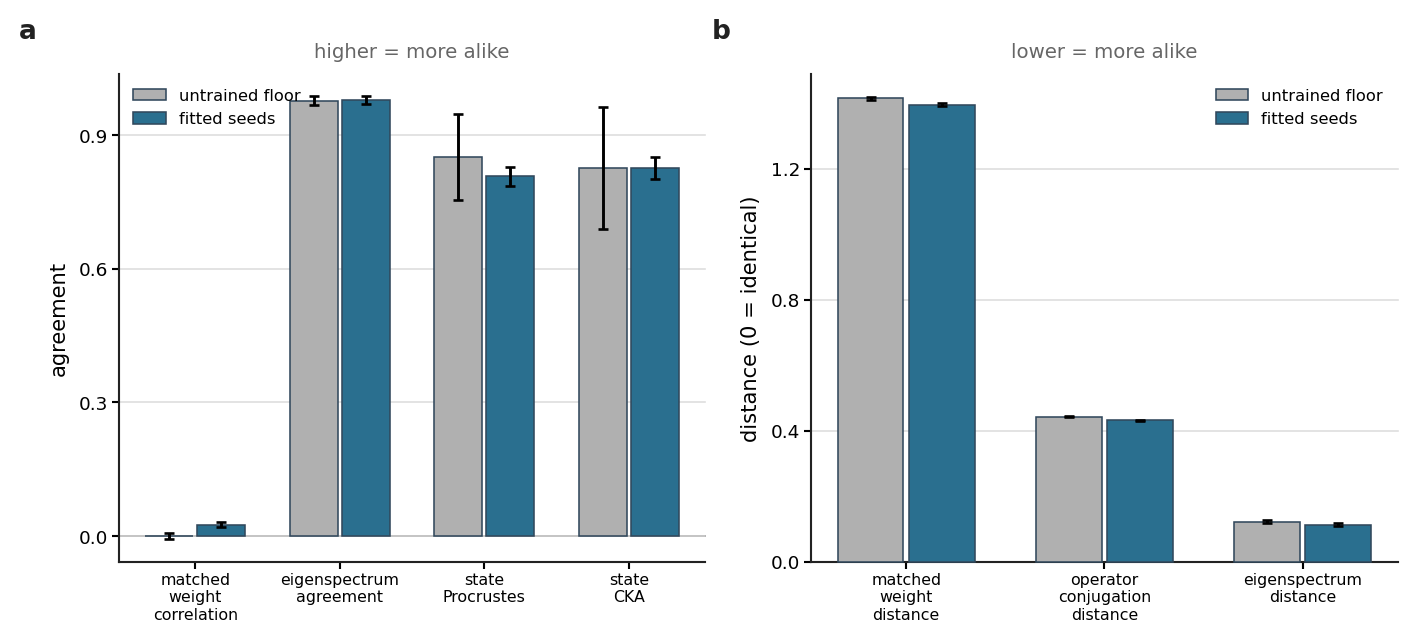

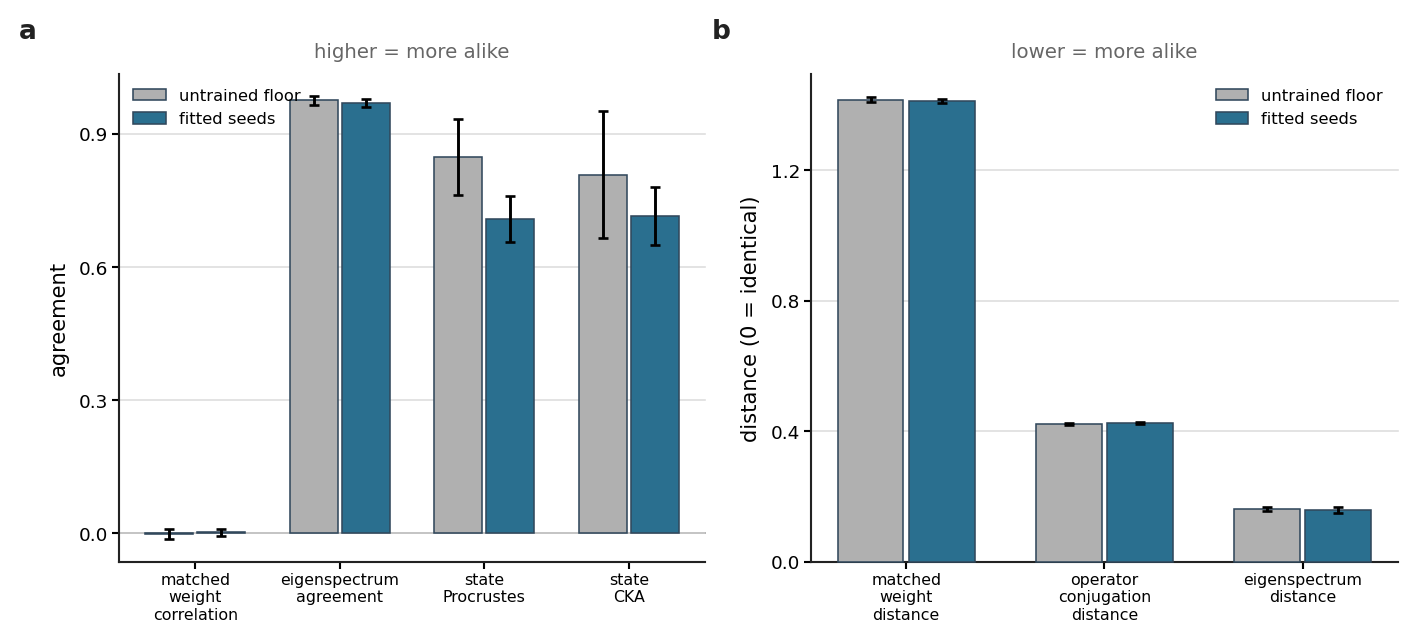

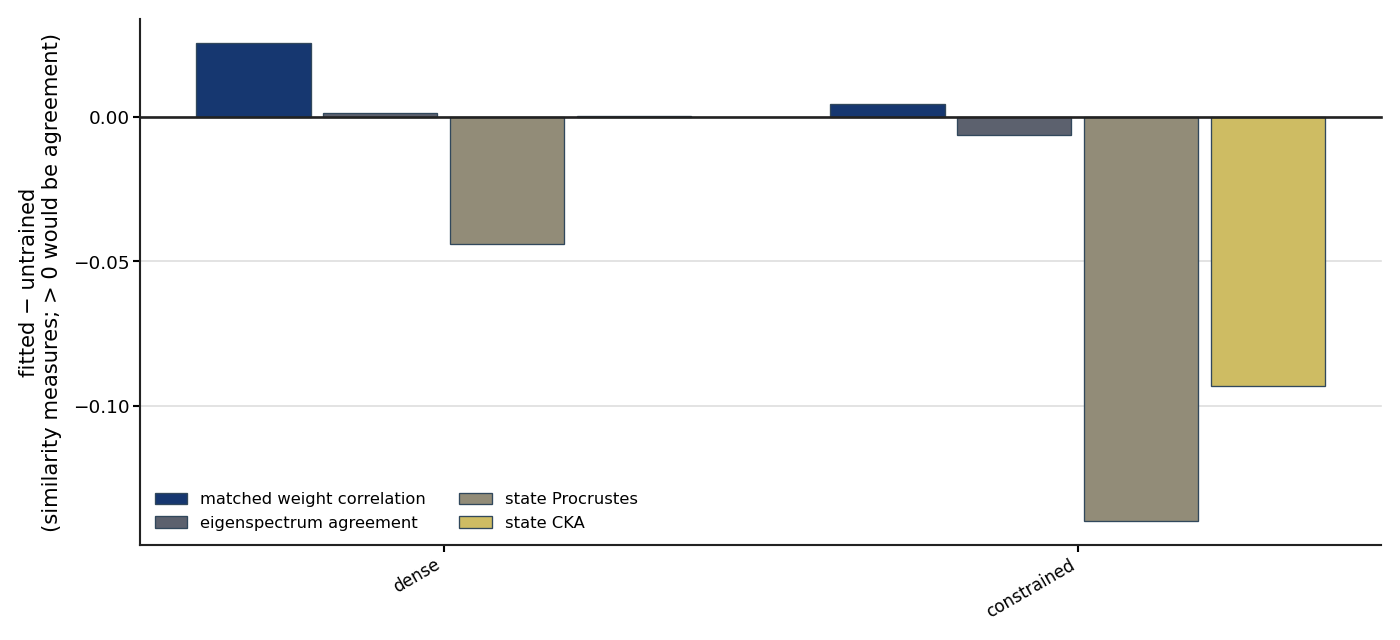

In [14]:
if fit is not None and "dense" in ARMS:
    battery = cached("agreement_battery", lambda: pd.concat(
        [audit.agreement_battery(audit.seed_run_dirs(p)).assign(arm=name) for name, p in ARMS.items()]
        + [audit.untrained_agreement_battery(audit.seed_run_dirs(p)[0], n_draws=6).assign(arm=name)
           for name, p in ARMS.items()], ignore_index=True))
    for name in ARMS:
        show(aviz.plot_agreement_battery(battery, audit.AGREEMENT_BATTERY, arm=name), f"fig29_battery_{name}")
    sim_names = [n for n, _, k in audit.AGREEMENT_BATTERY if k == "similarity"]
    show(aviz.plot_battery_across_arms(battery, sim_names, arm_order=list(ARMS)), "fig30_margins_constrained_vs_dense")

## 9. Consistency across the ten fits

Two scoreboards. **Ordering**: for every per-condition quantity in this notebook, the
fraction of fits in which interactive face is the lowest (drawn to the left) or the highest
(to the right), and the separation between conditions relative to the seed spread. A bar
at ±1 with separation above 1 is a property of the solution set. **Similarity**: the
complete version of §4's board — every property including the lesion profile and the fixed
points, the fraction of fits in which the two faces are the closest pair.

What holds in 10/10 fits of both arms: interactive face has the lowest fit, the lowest
drive and state dimensionality, the slowest and smallest state, the slowest trajectory end,
and (9–10/10) the steadiest cross share and the most expanding modes along its trajectory.
What does not hold: the origin of its drive (cross share), its alignment under the
constraint, its fixed-point count and stability, and every lesion total. On similarity, the
state (10/10) and the fixed points (8/10 constrained) keep the data's face–face ordering;
routing and lesions do not.

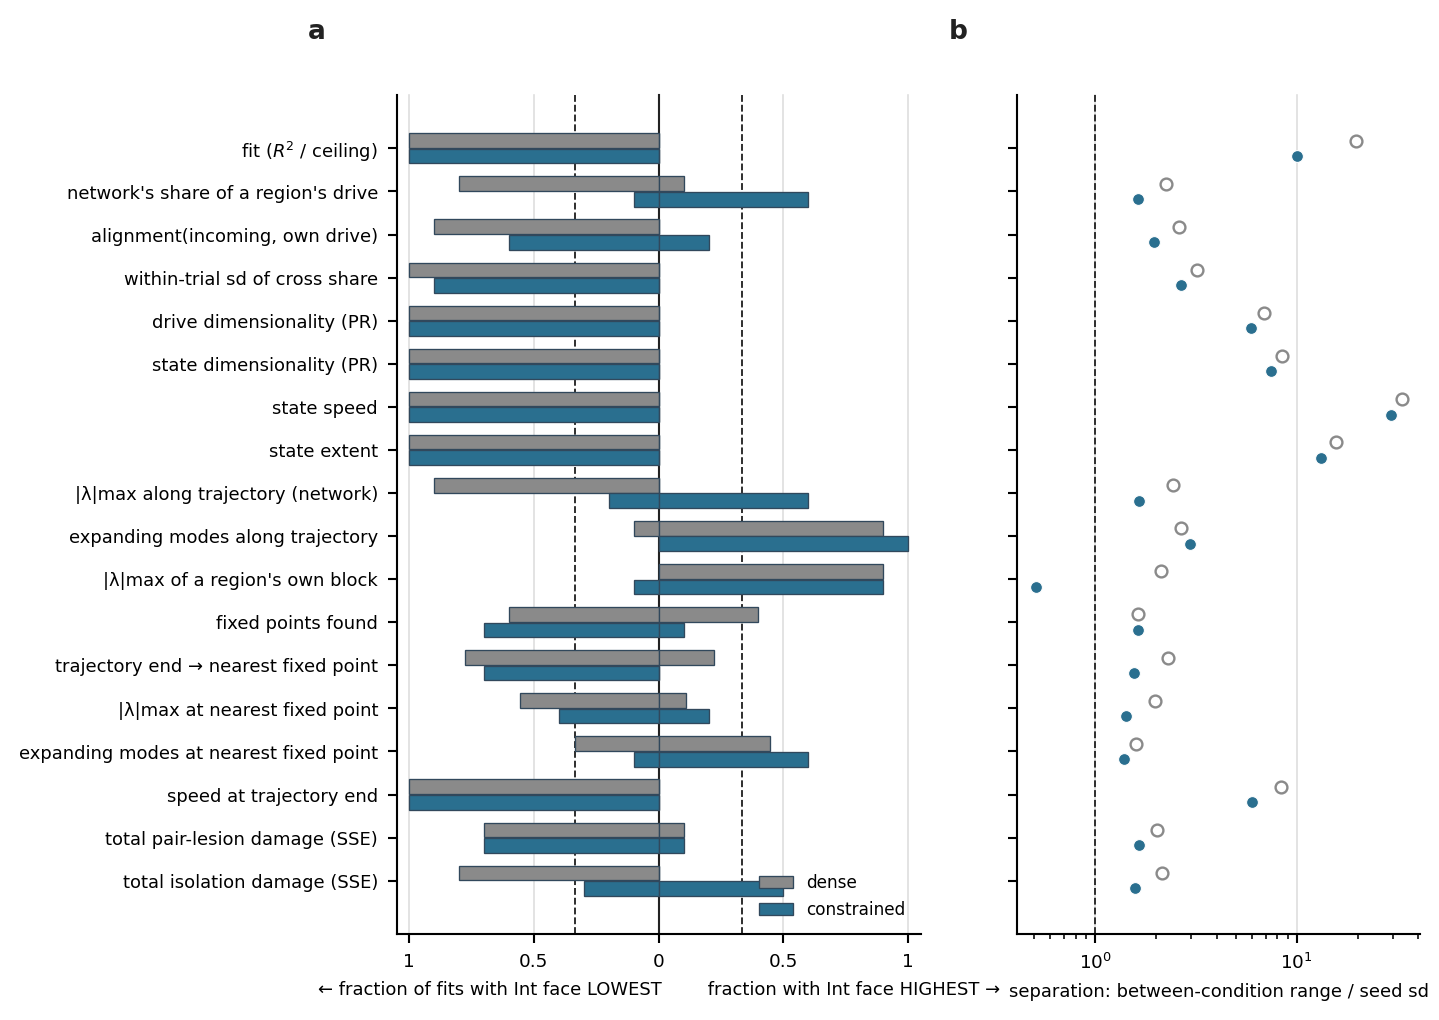

n_fits  fi_lowest  fi_highest  \
property                           arm                                          
r2_vs_ceiling                      constrained      10       1.00        0.00   
                                   dense            10       1.00        0.00   
cross_energy_fraction              constrained      10       0.10        0.60   
                                   dense            10       0.80        0.10   
alignment                          constrained      10       0.60        0.20   
                                   dense            10       0.90        0.00   
cross_fraction_modulation          constrained      10       0.90        0.00   
                                   dense            10       1.00        0.00   
drive_pr                           constrained      10       1.00        0.00   
                                   dense            10       1.00        0.00   
state_pr                           constrained      10       1.00        0.00   
                                   dense            10       1.00        0.00   
state_speed                        constrained      10       1.00        0.00   
                                   dense            10       1.00        0.00   
state_extent                       constrained      10       1.00        0.00   
                                   dense            10       1.00        0.00   
network_top_modulus                constrained      10       0.20        0.60   
                                   dense            10       0.90        0.00   
network_n_expanding                constrained      10       0.00        1.00   
                                   dense            10       0.10        0.90   
region_top_modulus                 constrained      10       0.10        0.90   
                                   dense            10       0.00        0.90   
n_fixed_points                     constrained      10       0.70        0.10   
                                   dense            10       0.60        0.40   
nearest_distance_to_trajectory_end constrained      10       0.70        0.00   
                                   dense             9       0.78        0.22   
nearest_top_modulus                constrained      10       0.40        0.20   
                                   dense             9       0.56        0.11   
nearest_n_expanding                constrained      10       0.10        0.60   
                                   dense             9       0.33        0.44   
trajectory_end_speed               constrained      10       1.00        0.00   
                                   dense            10       1.00        0.00   
pair_damage_total                  constrained      10       0.70        0.10   
                                   dense            10       0.70        0.10   
isolation_damage_total             constrained      10       0.30        0.50   
                                   dense            10       0.80        0.00   

                                                                                     modal_order  \
property                           arm                                                             
r2_vs_ceiling                      constrained  face_interactive < object < face_non_interactive   
                                   dense        face_interactive < object < face_non_interactive   
cross_energy_fraction              constrained  face_non_interactive < object < face_interactive   
                                   dense        face_interactive < face_non_interactive < object   
alignment                          constrained  face_interactive < face_non_interactive < object   
                                   dense        face_interactive < object < face_non_interactive   
cross_fraction_modulation          constrained  face_interactive < object < face_non_interactive   
                                   dense        face_interactive < fa

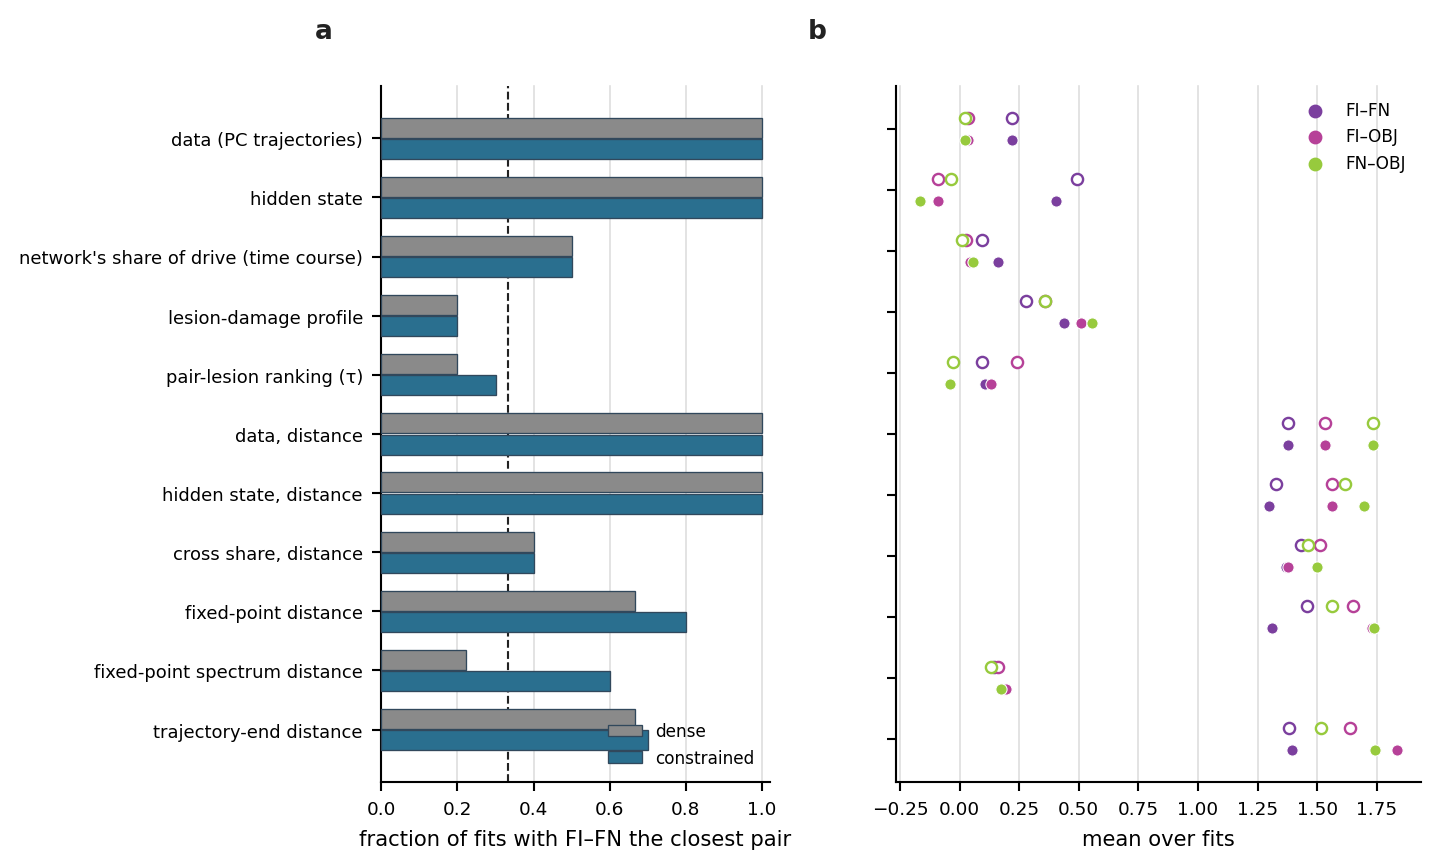

n_fits  FI–FN  FI–OBJ  FN–OBJ  \
property                      arm                                          
target                        constrained      10  0.218   0.034   0.021   
                              dense            10  0.218   0.034   0.021   
state                         constrained      10  0.403  -0.089  -0.165   
                              dense            10  0.494  -0.091  -0.034   
cross_share                   constrained      10  0.160   0.043   0.054   
                              dense            10  0.096   0.026   0.009   
lesion_profile                constrained      10  0.436   0.510   0.555   
                              dense            10  0.279   0.358   0.359   
lesion_ranking_bidirectional  constrained      10  0.107   0.133  -0.040   
                              dense            10  0.093   0.240  -0.027   
target_distance               constrained      10  1.380   1.535   1.734   
                              dense            10  1.380   1.535   1.734   
state_distance                constrained      10  1.297   1.564   1.695   
                              dense            10  1.328   1.563   1.618   
cross_share_distance          constrained      10  1.367   1.376   1.501   
                              dense            10  1.431   1.513   1.463   
fixed_point_distance          constrained      10  1.312   1.730   1.741   
                              dense             9  1.456   1.652   1.564   
fixed_point_spectrum_distance constrained      10  0.185   0.195   0.174   
                              dense             9  0.144   0.163   0.130   
trajectory_end_distance       constrained      10  1.394   1.834   1.742   
                              dense             9  1.384   1.637   1.517   

                                           fi_fn_closest  
property                      arm                         
target                        constrained          1.000  
                              dense                1.000  
state                         constrained          1.000  
                              dense                1.000  
cross_share                   constrained          0.500  
                              dense                0.500  
lesion_profile                constrained          0.200  
                              dense                0.200  
lesion_ranking_bidirectional  constrained          0.300  
                              dense                0.200  
target_distance               constrained          1.000  
                              dense                1.000  
state_distance                constrained          1.000  
                              dense                1.000  
cross_share_distance          constrained          0.400  
                              dense                0.400  
fixed_point_distance          constrained          0.800  
                              dense                0.667  
fixed_point_spectrum_distance constrained          0.600  
                              dense                0.222  
trajectory_end_distance       constrained          0.700  
                              dense                0.667

In [15]:
if fit is not None:
    fit_long = fit.groupby(["arm", "seed", "condition"])["r2_vs_ceiling"].mean().reset_index().rename(columns={"r2_vs_ceiling": "value"}).assign(property="r2_vs_ceiling")
    fp_long = ens.to_long(fp_summary, ["n_fixed_points", "nearest_distance_to_trajectory_end", "nearest_top_modulus", "nearest_n_expanding", "trajectory_end_speed"])
    pair_long = (pairs.groupby(["arm", "seed", "condition"])["damage_sse"].sum().reset_index()
                 .rename(columns={"damage_sse": "value"}).assign(property="pair_damage_total"))
    iso_long = (lesions[lesions["lesion_kind"] == "isolation"].groupby(["arm", "seed", "condition"])["damage_sse"].sum().reset_index()
                .rename(columns={"damage_sse": "value"}).assign(property="isolation_damage_total"))
    everything = pd.concat([fit_long, long_props, align_long, mod_long, jac_long, fp_long, pair_long, iso_long], ignore_index=True)
    board = ens.ordering_consistency(everything)
    board.to_csv(TASK_ROOT / "tables" / "ordering_consistency.csv", index=False)
    order = ["r2_vs_ceiling", "cross_energy_fraction", "alignment", "cross_fraction_modulation", "drive_pr", "state_pr",
             "state_speed", "state_extent", "network_top_modulus", "network_n_expanding", "region_top_modulus",
             "n_fixed_points", "nearest_distance_to_trajectory_end", "nearest_top_modulus", "nearest_n_expanding", "trajectory_end_speed",
             "pair_damage_total", "isolation_damage_total"]
    order = [p for p in order if p in set(board["property"])]
    show(eviz.plot_consistency_scoreboard(board, properties=order, labels=PROPERTY_LABELS, figsize=(7.6, 5.4)), "fig31_ordering_scoreboard")
    display(board.set_index(["property", "arm"]).loc[order][["n_fits", "fi_lowest", "fi_highest", "modal_order", "modal_order_fraction", "separation"]].round(2))

    all_similarity = pd.concat([net, lesion_sim, cross_rank, fp_distances], ignore_index=True)
    full_summary = ens.similarity_summary(all_similarity)
    full_summary.to_csv(TASK_ROOT / "tables" / "similarity_summary.csv", index=False)
    sim_order = ["target", "state", "cross_share", "lesion_profile", "lesion_ranking_bidirectional",
                 "target_distance", "state_distance", "cross_share_distance", "fixed_point_distance", "fixed_point_spectrum_distance", "trajectory_end_distance"]
    sim_order = [p for p in sim_order if p in set(full_summary["property"])]
    show(eviz.plot_similarity_scoreboard(full_summary, properties=sim_order, labels=PROPERTY_LABELS, figsize=(7.6, 4.6)), "fig32_similarity_scoreboard")
    display(full_summary.set_index(["property", "arm"]).loc[sim_order][["n_fits", "FI–FN", "FI–OBJ", "FN–OBJ", "fi_fn_closest"]].round(3))

## 10. Reading the result

**The bottleneck's cost is not evenly spread.** Squeezing the inter-regional channel to
rank 10 (and self-recurrence to rank 1) costs interactive face a third more fit than either
other fixation type, with a CI that excludes equality and a scale-free reading that agrees.
Combined with 02b: interactive face is the hardest fixation type in every network *and* the
one the channel carries most.

**The two faces are alike in the data and more alike in the model.** The network's state
keeps the data's face–face proximity in every fit and doubles it. Its drive routing does
not carry the distinction at all, and neither do its lesions — the fixation types are hurt by
the same connections in the same proportions.

**Interactive face has a dynamical signature every fit reproduces.** A small, slow,
low-dimensional trajectory that ends nearest a fixed point, threads the most locally
expansive region of the flow, and is the one fixation type whose trajectory a pair lesion
does not shrink — the other two lose 40–55% of their extent whichever pair is cut. None of
this depends on which pair is cut, because which pair matters is the one thing the ten fits
never agree on. The chapter's ensemble claim is
therefore pitched at the level of dynamics and condition contrast, not circuit: the
solution set has a reproducible portrait of the interactive-face state and no reproducible
wiring.

**Two caveats stated in the figures.** The selected model sits at the adequacy bar, not
above it (worst condition 0.983 against 0.98; worst region × condition cell 0.979). And
scale-carrying contrasts — extent, speed, dimensionality — are properties of the data that
any adequate fit must show (the target-side control in the audit); the scale-free ones
(expanding modes, end-speed relative to the fixed point, the sign of a lesion's effect on
extent) are the model's own.